# Rethinking Chicago Theft Crime Analysis

## Introduction

In this analysis, we will explore the crime data of Chicago to identify patterns and trends. We will use various data visualization techniques to gain insights into the types of crimes, their locations, and the times they occur.

We will focus on theft-related crimes in the end, but will briefly analyze the overall crime data to understand the context of thefts within the broader crime landscape of Chicago.

## Data Collection

> Thanks to These projects:
> - https://www.kaggle.com/fahd09/eda-of-crime-in-chicago-2005-2016
> - 朱小波, 李昕, 叶信岳. 数据关联背景下芝加哥市一般盗窃案件的多维度分析[J]. 犯罪研究, 2018(4):10.

## Data Loading and Cleaning

Before we can analyze the data, we need to preprocess it. This includes handling missing values, converting data types, and creating new features if necessary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn", low_memory=False)
Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn", low_memory=False)
Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn", low_memory=False)
Crime_2012_to_2017 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2012_to_2017.csv", on_bad_lines="warn", low_memory=False)

C:\Users\hanpeng\AppData\Local\Temp\ipykernel_51532\1354416516.py:2: ParserWarning: Skipping line 533719: expected 23 fields, saw 24

  Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn", low_memory=False)
C:\Users\hanpeng\AppData\Local\Temp\ipykernel_51532\1354416516.py:3: ParserWarning: Skipping line 1149094: expected 23 fields, saw 41

  Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn", low_memory=False)


Verify all dataframes have the same columns

In [4]:
print(Crime_2001_to_2004.columns)
print(Crime_2005_to_2007.columns)
print(Crime_2008_to_2011.columns)
print(Crime_2012_to_2017.columns)

print("All dataframes have the same columns: ",
      set(Crime_2001_to_2004.columns) == set(Crime_2005_to_2007.columns) == set(Crime_2008_to_2011.columns) == set(Crime_2012_to_2017.columns))


Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Lo

Combine all dataframes into one for easier analysis

In [5]:
Crime_data = pd.concat([Crime_2001_to_2004, Crime_2005_to_2007, Crime_2008_to_2011, Crime_2012_to_2017], ignore_index=True)
del Crime_2001_to_2004
del Crime_2005_to_2007
del Crime_2008_to_2011
del Crime_2012_to_2017
gc.collect()
Crime_data.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,424,4.0,7.0,46.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,935,9.0,11.0,61.0,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229156,-87.637328,"(41.817229156, -87.637328162)"
2,2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,False,1413,14.0,35.0,22.0,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
3,2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,False,2521,25.0,31.0,20.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,2233,22.0,34.0,49.0,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691784636,-87.635116,"(41.691784636, -87.635115968)"


Handle duplicate entries

In [6]:
print("Before handling duplicates: ", Crime_data.shape)
Crime_data.drop_duplicates(inplace=True)
print("After handling duplicates: ", Crime_data.shape)

Before handling duplicates:  (7941282, 23)
After handling duplicates:  (6170813, 23)


Convert 'Date' column to datetime format

In [7]:
Crime_data['Date'] = pd.to_datetime(Crime_data['Date'], format="%m/%d/%Y %I:%M:%S %p")

In [8]:
Crime_data.dtypes

Unnamed: 0                       int64
ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                        object
X Coordinate                   float64
Y Coordinate                    object
Year                           float64
Updated On                      object
Latitude                        object
Longitude                      float64
Location                        object
dtype: object

### Are IDs unique?

In [9]:
# Count cases with the same id and their counts
id_counts = Crime_data['ID'].value_counts()
duplicate_ids = id_counts[id_counts > 1]
print(f"Number of duplicate IDs: {len(duplicate_ids)}")
print(duplicate_ids.head())

Number of duplicate IDs: 1
ID
1423259    2
Name: count, dtype: int64


In [10]:
# Display these duplicate IDs and their corresponding rows, sorted by ID
duplicate_rows = Crime_data[Crime_data['ID'].isin(duplicate_ids.index)].sort_values(by='ID')
duplicate_rows
# duplicate_rows.iloc[90:96]

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
89258,3629582,1423259,G139165,2001-03-10 23:30:00,035XX S FEDERAL ST,1340,CRIMINAL DAMAGE,TO STATE SUP PROP,CHA PARKING LOT/GROUNDS,True,False,211,2.0,NaN,NaN,14,1176246.0,1881591.0,2001.000000,08/17/2015 03:03:40 PM,41.830443262,-87.628849,"(41.830443262, -87.628848503)"
1602847,3629582,1423259,G139165,2001-03-10 23:30:00,035XX S FEDERAL ST,1340,CRIMINAL DAMAGE,TO STATE SUP PROP,CHA PARKING LOT/GROUNDS,True,False,211,2.0,NaN,NaN,14,1176246.0,18 08:55:02 AM,41.789832,-87.672973835,"(41.789832136, -87.672973835)",NaN,NaN


So we remove 1602847 because it looks wrong and is duplicated in the dataset. We will check for other potential misaligned rows later.

In [11]:
# remove the duplicated row with index 1602847 because it looks wrong and is duplicated in the dataset
Crime_data.drop(index=1602847, inplace=True)
del duplicate_rows
gc.collect()

7

### Data Quality Assessment

Check for missing values and wrong data types, and row misalignment

In [12]:
# Data quality assessment: missing values, wrong data types, and possible row misalignment

print(f"Rows: {len(Crime_data):,} | Columns: {Crime_data.shape[1]}")

# 1) Missing values
missing_summary = (
    Crime_data.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(Crime_data) * 100).round(3)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

print("\nColumns with missing values:")
print(missing_summary)

# 2) Wrong data types / malformed values
numeric_cols = [
    "Unnamed: 0", "ID", "Beat", "District", "Ward", "Community Area",
    "X Coordinate", "Y Coordinate", "Year", "Latitude", "Longitude"
]

type_issues = {}
for col in numeric_cols:
    if col in Crime_data.columns:
        bad_mask = Crime_data[col].notna() & pd.to_numeric(Crime_data[col], errors="coerce").isna()
        bad_count = int(bad_mask.sum())
        if bad_count > 0:
            type_issues[col] = bad_count

# Date column validation
date_bad = Crime_data["Date"].isna().sum() if "Date" in Crime_data.columns else None

# Updated On validation (string datetime in source data)
updated_on_bad = None
if "Updated On" in Crime_data.columns:
    updated_on_parsed = pd.to_datetime(Crime_data["Updated On"], errors="coerce")
    updated_on_bad = int(Crime_data["Updated On"].notna().sum() - updated_on_parsed.notna().sum())

print("\nPotential type issues (non-null values that fail expected parsing):")
print(type_issues if type_issues else "None found")

print(f"\nUnparseable Date values: {date_bad:,}" if date_bad is not None else "\nDate column not found")
print(f"Unparseable Updated On values: {updated_on_bad:,}" if updated_on_bad is not None else "Updated On column not found")

# 3) Row misalignment checks (heuristics)
year_num = pd.to_numeric(Crime_data["Year"], errors="coerce")
lat_num = pd.to_numeric(Crime_data["Latitude"], errors="coerce")
lon_num = pd.to_numeric(Crime_data["Longitude"], errors="coerce")
ycoord_str = Crime_data["Y Coordinate"].astype(str)

reason_parts = pd.Series([""] * len(Crime_data), index=Crime_data.index)

missing_id_mask = Crime_data["ID"].isna()
bad_year_mask = year_num.notna() & ~year_num.between(2001, 2017)
bad_lat_mask = lat_num.notna() & ~lat_num.between(30, 50)
bad_lon_mask = lon_num.notna() & ~lon_num.between(-125, -65)
bad_ycoord_mask = ycoord_str.str.contains("AM|PM|:", na=False)

reason_parts[missing_id_mask] += "missing ID; "
reason_parts[bad_year_mask] += f"year out of range ({year_num[bad_year_mask].unique().tolist()}); "
reason_parts[bad_lat_mask] += "latitude out of Chicago range; "
reason_parts[bad_lon_mask] += "longitude out of Chicago range; "
reason_parts[bad_ycoord_mask] += "time-like string in Y Coordinate; "

misaligned_mask = missing_id_mask | bad_year_mask | bad_lat_mask | bad_lon_mask | bad_ycoord_mask

misaligned_rows = Crime_data[misaligned_mask].copy()
misaligned_rows["suspicious_reason"] = reason_parts[misaligned_mask].str.rstrip("; ")

print(f"\nPotentially misaligned/suspicious rows: {len(misaligned_rows):,}")

if len(misaligned_rows) > 0:
    # display_cols = [
    #     "ID", "Case Number", "Date", "Block", "Y Coordinate", "Year",
    #     "Updated On", "Latitude", "Longitude", "Location"
    # ]
    # display(misaligned_rows[display_cols].head(10))
    display(misaligned_rows.head(4))
    
    del misaligned_rows
    gc.collect()

Rows: 6,170,812 | Columns: 23

Columns with missing values:
                      missing_count  missing_pct
Community Area               616041        9.983
Ward                         614864        9.964
Longitude                     84223        1.365
Latitude                      84223        1.365
X Coordinate                  84223        1.365
Y Coordinate                  84223        1.365
Location                      84223        1.365
Location Description           1968        0.032
District                         49        0.001
Case Number                       4        0.000


C:\Users\hanpeng\AppData\Local\Temp\ipykernel_51532\2309877065.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  updated_on_parsed = pd.to_datetime(Crime_data["Updated On"], errors="coerce")



Potential type issues (non-null values that fail expected parsing):
None found

Unparseable Date values: 0
Unparseable Updated On values: 0

Potentially misaligned/suspicious rows: 0


## Exploratory Data Analysis

### Types of Crimes

In [13]:
unique_crimes = Crime_data['Primary Type'].unique().tolist()
print(f"Total unique crime types: {len(unique_crimes)}")
print(unique_crimes)

Total unique crime types: 35
['THEFT', 'OTHER OFFENSE', 'OFFENSE INVOLVING CHILDREN', 'CRIM SEXUAL ASSAULT', 'MOTOR VEHICLE THEFT', 'SEX OFFENSE', 'DECEPTIVE PRACTICE', 'BATTERY', 'BURGLARY', 'WEAPONS VIOLATION', 'PUBLIC PEACE VIOLATION', 'NARCOTICS', 'GAMBLING', 'PROSTITUTION', 'LIQUOR LAW VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER', 'CRIMINAL DAMAGE', 'ASSAULT', 'STALKING', 'ARSON', 'CRIMINAL TRESPASS', 'HOMICIDE', 'ROBBERY', 'OBSCENITY', 'KIDNAPPING', 'INTIMIDATION', 'RITUALISM', 'DOMESTIC VIOLENCE', 'OTHER NARCOTIC VIOLATION', 'PUBLIC INDECENCY', 'NON-CRIMINAL', 'HUMAN TRAFFICKING', 'CONCEALED CARRY LICENSE VIOLATION', 'NON - CRIMINAL', 'NON-CRIMINAL (SUBJECT SPECIFIED)']


Primary Type
THEFT                                1284608
BATTERY                              1125725
CRIMINAL DAMAGE                       710082
NARCOTICS                             674556
OTHER OFFENSE                         381714
ASSAULT                               376888
BURGLARY                              361624
MOTOR VEHICLE THEFT                   291030
ROBBERY                               233527
DECEPTIVE PRACTICE                    223245
CRIMINAL TRESPASS                     178002
PROSTITUTION                           65533
WEAPONS VIOLATION                      60640
PUBLIC PEACE VIOLATION                 44732
OFFENSE INVOLVING CHILDREN             40233
CRIM SEXUAL ASSAULT                    23607
SEX OFFENSE                            22631
GAMBLING                               13884
LIQUOR LAW VIOLATION                   13422
INTERFERENCE WITH PUBLIC OFFICER       12869
ARSON                                  10279
HOMICIDE                                82

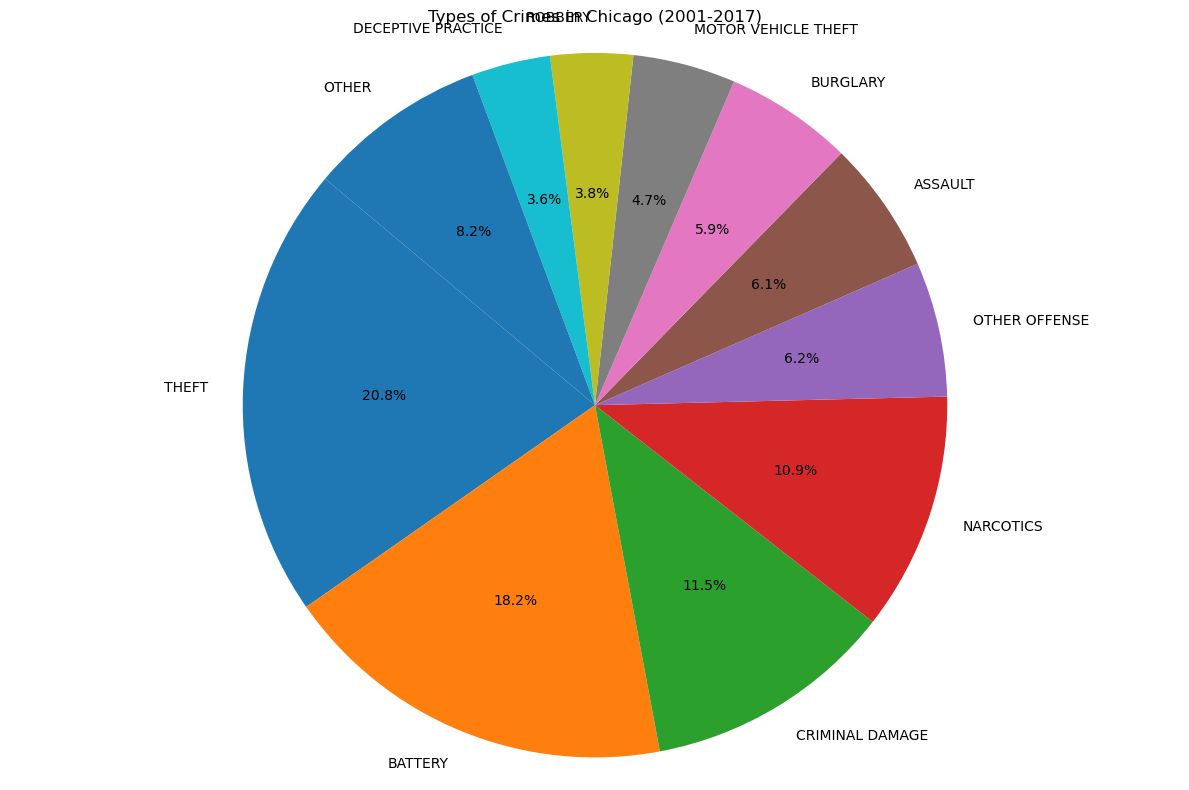

3272

In [14]:
crime_counts = Crime_data['Primary Type'].value_counts()
print(crime_counts)

top_crimes = crime_counts.head(10)
other_count = crime_counts.iloc[10:].sum()
plot_data = pd.concat([top_crimes, pd.Series({'OTHER': other_count})])

plt.figure(figsize=(12, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Types of Crimes in Chicago (2001-2017)')
plt.axis('equal')
plt.tight_layout()
plt.show()

del crime_counts, top_crimes, other_count, plot_data
gc.collect()

### Non-geographic Missing values?

In [15]:
# Check missing values across all columns
missing_counts = Crime_data.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": (missing_counts / len(Crime_data) * 100).round(2)
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:\n")
print(missing_summary)

# Test whether missing data is only in geographic fields
geo_cols = ["X Coordinate", "Y Coordinate", "Latitude", "Longitude", "Location"]
non_geo_missing = [col for col in missing_summary.index if col not in geo_cols]

if not non_geo_missing:
    print("\nYes — missing values are only in geographic information columns.")
else:
    print("\nNo — there are missing values in non-geographic columns too:")
    print(non_geo_missing)
    
del missing_counts, missing_summary, non_geo_missing
gc.collect()

Columns with missing values:

                      missing_count  missing_pct
Community Area               616041         9.98
Ward                         614864         9.96
X Coordinate                  84223         1.36
Location                      84223         1.36
Y Coordinate                  84223         1.36
Longitude                     84223         1.36
Latitude                      84223         1.36
Location Description           1968         0.03
District                         49         0.00
Case Number                       4         0.00

No — there are missing values in non-geographic columns too:
['Community Area', 'Ward', 'Location Description', 'District', 'Case Number']


0

What are the case numbers that are missing?

In [16]:
missing_case_rows = Crime_data[Crime_data["Case Number"].isna()]

print(f"Number of missing case numbers: {len(missing_case_rows)}")
# missing_case_rows[["ID", "Date", "Block", "Primary Type", "Case Number"]]
missing_case_rows

Number of missing case numbers: 4


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4425181,1503746,7014449,NaN,2009-07-10 11:00:00,082XX S HARPER AVE,0560,ASSAULT,SIMPLE,STREET,False,False,411,4.0,8.0,45.0,08A,1187910.0,1850555.0,2009.0,02/04/2016 06:33:39 AM,41.745008,-87.587042,"(41.74500765, -87.587041972)"
4447882,1526447,7049552,NaN,2009-07-30 03:00:00,058XX N PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2012,20.0,40.0,77.0,14,1164170.0,1938694.0,2009.0,02/04/2016 06:33:39 AM,41.987401,-87.671539,"(41.987401038, -87.671539153)"
4809787,1888354,7610078,NaN,2010-07-16 14:56:00,005XX W VAN BUREN ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,111,1.0,2.0,28.0,08B,1172646.0,1898435.0,2010.0,02/04/2016 06:33:39 AM,41.876745,-87.641559,"(41.876744768, -87.641559043)"
7759089,5192747,8475075,NaN,2012-02-08 22:00:00,032XX N KILDARE AVE,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,1731,17.0,31.0,16.0,05,NaN,NaN,2012.0,05/04/2016 03:48:23 PM,NaN,NaN,NaN


In [17]:
# Find cases with id appeeared in missing case rows in the dataset
missing_case_ids = missing_case_rows["ID"].dropna().unique()
print(f"Unique IDs in missing case rows: {len(missing_case_ids)}")

Crime_data[Crime_data["ID"].isin(missing_case_ids)]

Unique IDs in missing case rows: 4


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4425181,1503746,7014449,NaN,2009-07-10 11:00:00,082XX S HARPER AVE,0560,ASSAULT,SIMPLE,STREET,False,False,411,4.0,8.0,45.0,08A,1187910.0,1850555.0,2009.0,02/04/2016 06:33:39 AM,41.745008,-87.587042,"(41.74500765, -87.587041972)"
4447882,1526447,7049552,NaN,2009-07-30 03:00:00,058XX N PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2012,20.0,40.0,77.0,14,1164170.0,1938694.0,2009.0,02/04/2016 06:33:39 AM,41.987401,-87.671539,"(41.987401038, -87.671539153)"
4809787,1888354,7610078,NaN,2010-07-16 14:56:00,005XX W VAN BUREN ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,111,1.0,2.0,28.0,08B,1172646.0,1898435.0,2010.0,02/04/2016 06:33:39 AM,41.876745,-87.641559,"(41.876744768, -87.641559043)"
7759089,5192747,8475075,NaN,2012-02-08 22:00:00,032XX N KILDARE AVE,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,1731,17.0,31.0,16.0,05,NaN,NaN,2012.0,05/04/2016 03:48:23 PM,NaN,NaN,NaN


So cases numbers are missing in the dataset, but we can still analyze the data based on other features.

### Missing Value percentage for each type of crime

In [18]:
# Calculate missing percentage by crime type for each column
missing_by_crime_type = {}

for crime_type in Crime_data["Primary Type"].unique():
    crime_data = Crime_data[Crime_data["Primary Type"] == crime_type]
    missing_counts = crime_data.isna().sum()
    missing_pct = (missing_counts / len(crime_data) * 100).round(2)
    missing_by_crime_type[crime_type] = missing_pct

# Create a DataFrame with crime types as rows and columns as columns
missing_pct_by_crime_type = pd.DataFrame(missing_by_crime_type).T

# Display only columns that have missing values in at least one crime type
cols_with_missing = missing_pct_by_crime_type.columns[missing_pct_by_crime_type.sum(axis=0) > 0]
missing_pct_by_crime_type_filtered = missing_pct_by_crime_type[cols_with_missing]

# Sort by the first column with missing values
print(f"Missing value percentage by crime type ({len(Crime_data['Primary Type'].unique())} crime types):\n")
if len(cols_with_missing) > 0:
    print(missing_pct_by_crime_type_filtered.sort_values(cols_with_missing[0], ascending=False))
else:
    print("No missing values found")

Missing value percentage by crime type (35 crime types):

                                   Location Description  District    Ward  \
DECEPTIVE PRACTICE                                 0.55      0.00    8.00   
THEFT                                              0.06      0.00    9.56   
OTHER OFFENSE                                      0.00      0.00   10.37   
OFFENSE INVOLVING CHILDREN                         0.00      0.00    6.39   
CRIM SEXUAL ASSAULT                                0.00      0.00    8.82   
MOTOR VEHICLE THEFT                                0.00      0.00   11.29   
SEX OFFENSE                                        0.00      0.01   11.33   
BATTERY                                            0.00      0.00   10.51   
BURGLARY                                           0.00      0.00    8.99   
WEAPONS VIOLATION                                  0.00      0.00    9.19   
PUBLIC PEACE VIOLATION                             0.00      0.00    7.64   
NARCOTICS         

In [19]:
missing_pct_by_crime_type_filtered

del missing_case_rows, missing_case_ids, missing_by_crime_type, missing_pct_by_crime_type, missing_pct_by_crime_type_filtered
gc.collect()

0

## Thefts Only EDA

### Keeping only thefts for further analysis

As we planned, we will focus on thefts for our analysis. We will filter the dataset to include only rows where the 'Primary Type' is 'THEFT'.

In [20]:
Theft_data = Crime_data[Crime_data["Primary Type"] == "THEFT"].copy()
print(f"Theft data shape: {Theft_data.shape}")
del Crime_data
gc.collect()

Theft data shape: (1284608, 23)


0

### Location Description Analysis

We will analyze the 'Location Description' feature to see where thefts are most likely to occur.

In [21]:
location_counts = (
    Theft_data["Location Description"]
    .fillna("MISSING")
    .value_counts()
    .rename_axis("Location Description")
    .reset_index(name="Occurrence")
)

location_counts

del location_counts
gc.collect()

0

### Theft and missing values

We will analyze the theft data to see if there are any patterns in the missing values. This can help us understand if there are any biases in the data that we need to account for in our analysis.

In [22]:
geo_na = Theft_data[geo_cols].isna()

geo_all_missing = geo_na.all(axis=1)
geo_any_missing = geo_na.any(axis=1)
geo_partial_missing = geo_any_missing & ~geo_all_missing

print(f"Total theft rows: {len(Theft_data):,}")
print(f"Rows with all 5 geographic fields missing: {geo_all_missing.sum():,}")
print(f"Rows with any geographic field missing: {geo_any_missing.sum():,}")
print(f"Rows with partial missingness among the 5 fields: {geo_partial_missing.sum():,}")

if geo_partial_missing.sum() == 0:
    print("\nVerified: X Coordinate, Y Coordinate, Latitude, Longitude, and Location are perfectly linked for missingness.")
    print("For missing-value analysis, one of these five fields is sufficient to represent the group.")
else:
    print("\nNot strictly linked. Partial missingness exists in these patterns:")
    print(
        geo_na.loc[geo_partial_missing]
        .apply(lambda row: ", ".join(row.index[row]), axis=1)
        .value_counts()
    )
    print("\nSample rows with partial missingness:")
    print(Theft_data.loc[geo_partial_missing, geo_cols].head(10))

del geo_na, geo_all_missing, geo_any_missing, geo_partial_missing
gc.collect()

Total theft rows: 1,284,608
Rows with all 5 geographic fields missing: 19,604
Rows with any geographic field missing: 19,604
Rows with partial missingness among the 5 fields: 0

Verified: X Coordinate, Y Coordinate, Latitude, Longitude, and Location are perfectly linked for missingness.
For missing-value analysis, one of these five fields is sufficient to represent the group.


0

### Missing percentage by year, unique month, and unique day

We will check how the missing rates of each feature, emphasizing `Ward`, `Community Area`, and `Location`, change across year, each unique calendar month, and each unique calendar day in the theft data.

Columns with non-zero missingness in theft data (9):
['Location Description', 'District', 'Ward', 'Community Area', 'X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude', 'Location']
Missing percentage by year:


,Location Description,District,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Location
Year,,,,,,,,,
2001,0.00,0.0,98.73,98.74,0.82,0.82,0.82,0.82,0.82
2002,0.00,0.0,25.22,25.22,3.02,3.02,3.02,3.02,3.02
2003,0.00,0.0,0.00,0.01,1.09,1.09,1.09,1.09,1.09
2004,0.00,0.0,0.00,0.01,1.01,1.01,1.01,1.01,1.01
2005,0.00,0.0,0.00,0.01,1.61,1.61,1.61,1.61,1.61
2006,0.00,0.0,0.00,0.01,1.17,1.17,1.17,1.17,1.17
2007,0.00,0.0,0.00,0.05,0.65,0.65,0.65,0.65,0.65
2008,0.00,0.0,0.00,0.08,2.29,2.29,2.29,2.29,2.29
2009,0.00,0.0,0.00,0.07,2.06,2.06,2.06,2.06,2.06


Missing percentage by unique month:


,Location Description,District,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Location
YearMonth,,,,,,,,,
2001-01,0.00,0.0,97.58,97.60,0.75,0.75,0.75,0.75,0.75
2001-02,0.00,0.0,99.27,99.27,0.63,0.63,0.63,0.63,0.63
2001-03,0.00,0.0,99.29,99.30,0.84,0.84,0.84,0.84,0.84
2001-04,0.00,0.0,99.01,99.01,0.93,0.93,0.93,0.93,0.93
2001-05,0.00,0.0,99.08,99.08,0.72,0.72,0.72,0.72,0.72
...,...,...,...,...,...,...,...,...,...
2016-09,0.00,0.0,0.00,0.00,3.57,3.57,3.57,3.57,3.57
2016-10,0.00,0.0,0.00,0.00,3.15,3.15,3.15,3.15,3.15
2016-11,0.02,0.0,0.00,0.00,3.07,3.07,3.07,3.07,3.07


Missing percentage by unique day (sample):


,Location Description,District,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Location
CalendarDate,,,,,,,,,
2001-01-01,0.0,0.0,65.69,65.69,1.95,1.95,1.95,1.95,1.95
2001-01-02,0.0,0.0,96.83,96.83,0.00,0.00,0.00,0.00,0.00
2001-01-03,0.0,0.0,99.56,99.56,0.00,0.00,0.00,0.00,0.00
2001-01-04,0.0,0.0,100.00,100.00,0.00,0.00,0.00,0.00,0.00
2001-01-05,0.0,0.0,99.62,99.62,1.13,1.13,1.13,1.13,1.13
2001-01-06,0.0,0.0,99.59,99.59,0.00,0.00,0.00,0.00,0.00
2001-01-07,0.0,0.0,99.02,99.02,1.95,1.95,1.95,1.95,1.95
2001-01-08,0.0,0.0,99.59,99.59,0.00,0.00,0.00,0.00,0.00
2001-01-09,0.0,0.0,100.00,100.00,0.38,0.38,0.38,0.38,0.38


Plotting each column separately with Year, Month, and raw Day granularity...


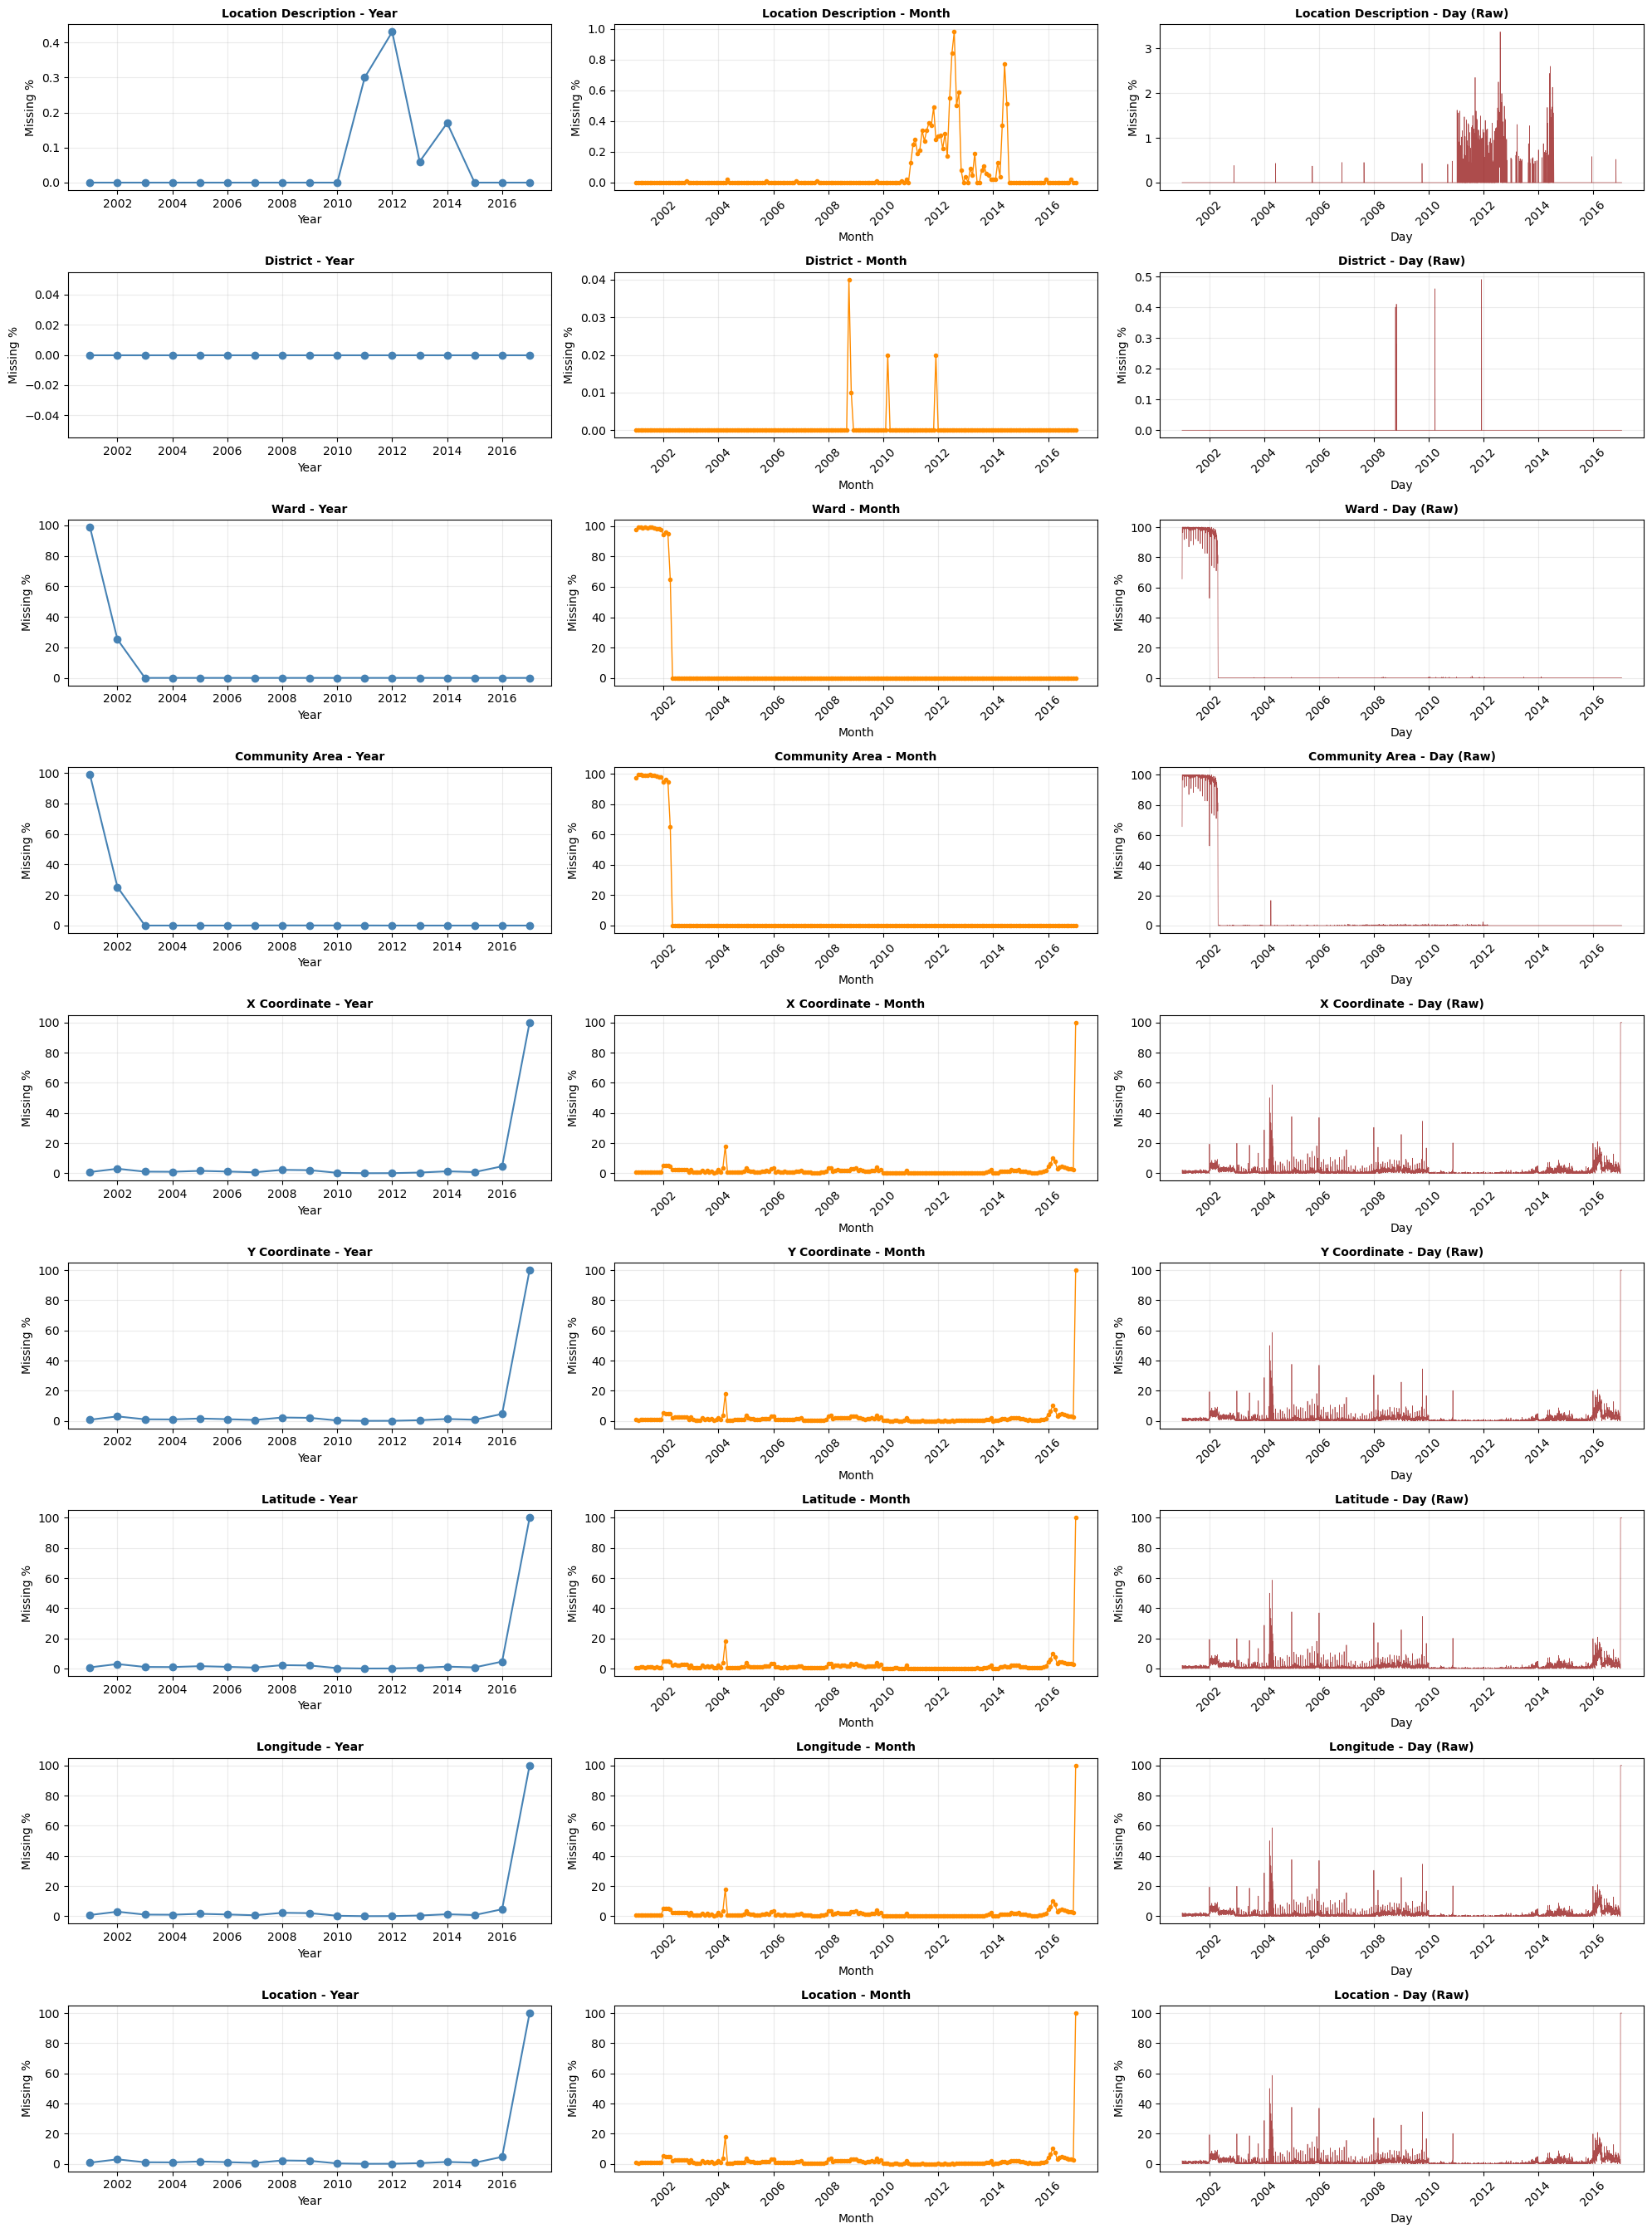

66

In [23]:
missing_cols_in_theft = Theft_data.columns[Theft_data.isna().any()].tolist()
print(f"Columns with non-zero missingness in theft data ({len(missing_cols_in_theft)}):")
print(missing_cols_in_theft)

time_frame = Theft_data.loc[:, ["Date"] + missing_cols_in_theft].copy()
time_frame["Year"] = time_frame["Date"].dt.year
time_frame["YearMonth"] = time_frame["Date"].dt.to_period("M")
time_frame["CalendarDate"] = time_frame["Date"].dt.normalize()

def missing_pct_by_period(frame, period_col, value_cols):
    summary = (
        frame.groupby(period_col)[value_cols]
        .apply(lambda group: group.isna().mean().mul(100).round(2))
        .sort_index()
    )
    return summary

missing_by_year = missing_pct_by_period(time_frame, "Year", missing_cols_in_theft)
missing_by_month = missing_pct_by_period(time_frame, "YearMonth", missing_cols_in_theft)
missing_by_day = missing_pct_by_period(time_frame, "CalendarDate", missing_cols_in_theft)

missing_by_month_display = missing_by_month.copy()
missing_by_month_display.index = missing_by_month_display.index.astype(str)

missing_by_day_display = missing_by_day.copy()
missing_by_day_display.index = missing_by_day_display.index.strftime("%Y-%m-%d")

month_plot = missing_by_month.copy()
month_plot.index = month_plot.index.to_timestamp()

print("Missing percentage by year:")
display(missing_by_year)

print("Missing percentage by unique month:")
display(missing_by_month_display)

print("Missing percentage by unique day (sample):")
display(missing_by_day_display.head(20))

print("Plotting each column separately with Year, Month, and raw Day granularity...")

# Create 9x3 grid: each row is a column (feature), each column is a granularity (Year, Month, Day)
fig, axes = plt.subplots(len(missing_cols_in_theft), 3, figsize=(20, 3 * len(missing_cols_in_theft)), sharey=False)

for row_idx, col in enumerate(missing_cols_in_theft):
    # Year plot
    axes[row_idx, 0].plot(missing_by_year.index, missing_by_year[col], marker="o", linewidth=1.5, color="steelblue")
    axes[row_idx, 0].set_title(f"{col} - Year", fontsize=10, fontweight="bold")
    axes[row_idx, 0].set_xlabel("Year")
    axes[row_idx, 0].set_ylabel("Missing %")
    axes[row_idx, 0].grid(True, alpha=0.25)
    
    # Month plot
    month_ts = month_plot.index
    axes[row_idx, 1].plot(month_ts, missing_by_month[col], marker="o", linewidth=1, color="darkorange", markersize=3)
    axes[row_idx, 1].set_title(f"{col} - Month", fontsize=10, fontweight="bold")
    axes[row_idx, 1].set_xlabel("Month")
    axes[row_idx, 1].set_ylabel("Missing %")
    axes[row_idx, 1].grid(True, alpha=0.25)
    axes[row_idx, 1].tick_params(axis="x", rotation=45)
    
    # Day plot (raw daily data)
    day_ts = missing_by_day.index
    axes[row_idx, 2].plot(day_ts, missing_by_day[col], linewidth=0.5, color="darkred", alpha=0.7)
    axes[row_idx, 2].set_title(f"{col} - Day (Raw)", fontsize=10, fontweight="bold")
    axes[row_idx, 2].set_xlabel("Day")
    axes[row_idx, 2].set_ylabel("Missing %")
    axes[row_idx, 2].grid(True, alpha=0.25)
    axes[row_idx, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

del time_frame, missing_by_year, missing_by_day, missing_by_month_display, missing_by_day_display
gc.collect()

So we can see the missing rates of each feature and calculate their trusted time range for analysis. We will focus on the time range where the missing rates are relatively low and stable for our further analysis of thefts in Chicago.

Trusted time intervals (monthly) for each factor (multi-segment):


,factor,segment_id,trusted_threshold_pct,trusted_start,trusted_end,trusted_months,avg_missing_in_interval_pct,max_missing_in_interval_pct
0,Community Area,1,0.07,2002-05,2008-04,72,0.02,0.14
1,Community Area,2,0.07,2008-07,2008-08,2,0.06,0.06
2,Community Area,3,0.07,2008-11,2009-09,11,0.06,0.10
3,Community Area,4,0.07,2010-01,2010-02,2,0.04,0.06
4,Community Area,5,0.07,2010-05,2011-06,14,0.05,0.09
5,Community Area,6,0.07,2011-09,2011-10,2,0.05,0.07
6,Community Area,7,0.07,2012-01,2017-01,61,0.00,0.07
7,District,1,0.01,2001-01,2017-01,193,0.00,0.04
8,Latitude,1,2.06,2001-01,2001-12,12,0.82,0.93
9,Latitude,2,2.06,2002-12,2004-02,15,1.11,2.48


Summary by factor:


,factor,n_segments,total_trusted_months,threshold_pct
1,District,1,193,0.01
6,Ward,2,175,0.01
0,Community Area,7,164,0.07
2,Latitude,7,156,2.06
3,Location,7,156,2.06
5,Longitude,7,156,2.06
7,X Coordinate,7,156,2.06
8,Y Coordinate,7,156,2.06
4,Location Description,4,155,0.01


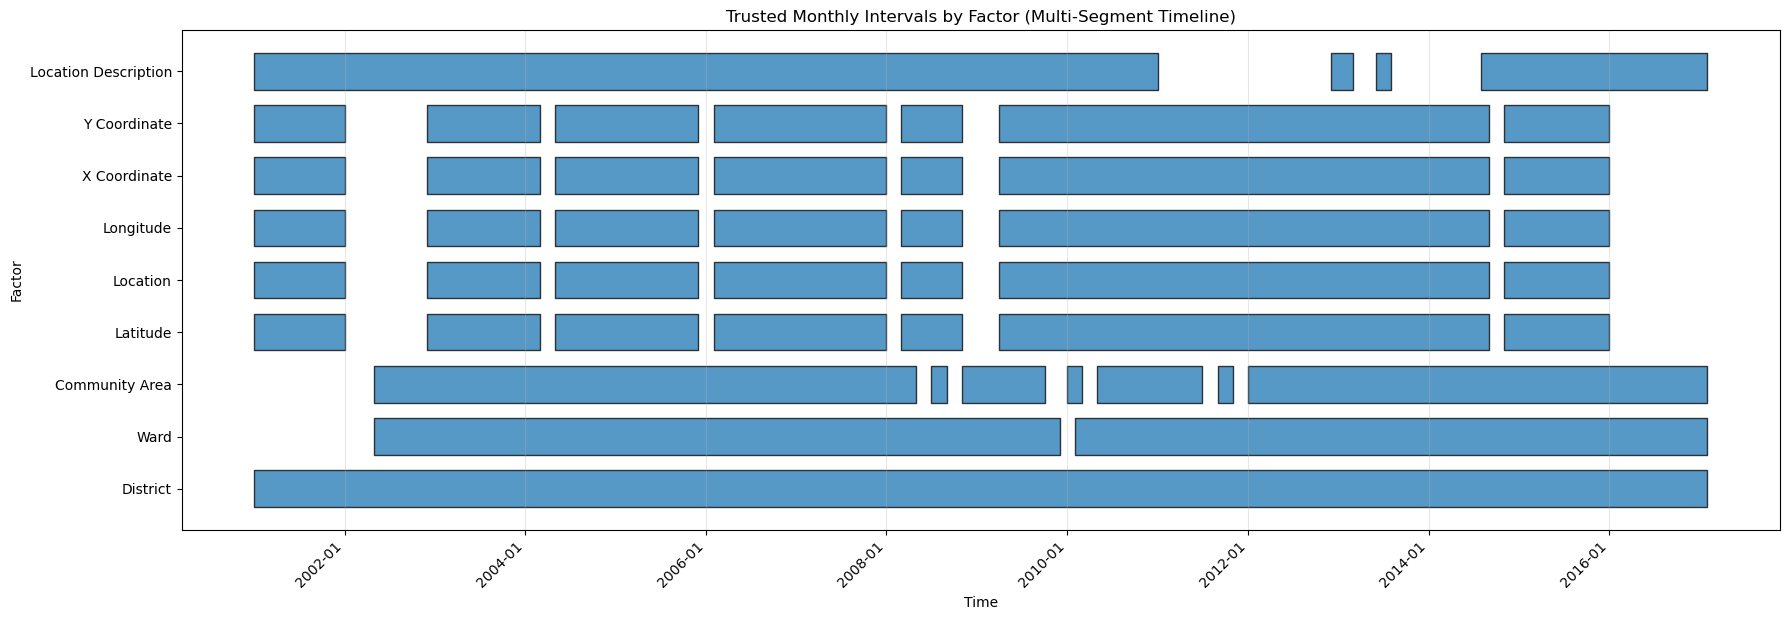

62

In [24]:
# Trusted time interval by factor (based on monthly missing-rate stability)
# Multi-interval version: keep all consecutive trusted monthly segments per factor.

# Factors mentioned above: use all theft columns with non-zero missingness
factors = [c for c in missing_cols_in_theft if c in missing_by_month.columns]

def split_consecutive_periods(period_index):
    """Split a PeriodIndex into consecutive monthly runs.
    Returns list of tuples: (start_period, end_period, length_months).
    """
    if len(period_index) == 0:
        return []

    ts = period_index.to_timestamp().sort_values()
    diffs = ts.to_series().diff().dt.days.fillna(31)
    groups = (diffs > 35).cumsum()  # break when gap > ~1 month

    segments = []
    for _, block in ts.to_series().groupby(groups):
        start = block.iloc[0].to_period("M")
        end = block.iloc[-1].to_period("M")
        length = (end - start).n + 1
        segments.append((start, end, length))

    return segments

results = []

for col in factors:
    s = missing_by_month[col].dropna().copy()

    # Adaptive threshold:
    # 1) remove worst 20% months as outliers
    # 2) trusted threshold = 95th percentile of remaining "normal" months
    normal_pool = s[s <= s.quantile(0.80)]
    raw_threshold = normal_pool.quantile(0.95) if len(normal_pool) > 0 else s.quantile(0.95)

    # Avoid threshold collapsing to 0 for nearly-complete factors like District.
    threshold = max(float(raw_threshold), 0.01)

    trusted_mask = s <= threshold

    # Bridge isolated one-month outliers:
    # if a bad month is surrounded by trusted months, keep continuity.
    bad = ~trusted_mask
    bridge = bad & trusted_mask.shift(1, fill_value=False) & trusted_mask.shift(-1, fill_value=False)
    trusted_mask = trusted_mask | bridge

    trusted_periods = s.index[trusted_mask]
    segments = split_consecutive_periods(trusted_periods)

    if len(segments) == 0:
        results.append({
            "factor": col,
            "segment_id": None,
            "trusted_threshold_pct": round(float(threshold), 2),
            "trusted_start": None,
            "trusted_end": None,
            "trusted_months": 0,
            "avg_missing_in_interval_pct": np.nan,
            "max_missing_in_interval_pct": np.nan,
        })
        continue

    for i, (start_p, end_p, n_months) in enumerate(segments, start=1):
        interval_slice = s.loc[start_p:end_p]
        avg_missing = interval_slice.mean()
        max_missing = interval_slice.max()

        results.append({
            "factor": col,
            "segment_id": i,
            "trusted_threshold_pct": round(float(threshold), 2),
            "trusted_start": str(start_p),
            "trusted_end": str(end_p),
            "trusted_months": int(n_months),
            "avg_missing_in_interval_pct": round(float(avg_missing), 2) if pd.notna(avg_missing) else np.nan,
            "max_missing_in_interval_pct": round(float(max_missing), 2) if pd.notna(max_missing) else np.nan,
        })

trusted_intervals = pd.DataFrame(results).sort_values(
    ["factor", "trusted_start"], ascending=[True, True]
).reset_index(drop=True)

trusted_interval_summary = (
    trusted_intervals.groupby("factor", dropna=False)
    .agg(
        n_segments=("segment_id", "count"),
        total_trusted_months=("trusted_months", "sum"),
        threshold_pct=("trusted_threshold_pct", "first"),
    )
    .reset_index()
    .sort_values(["total_trusted_months", "factor"], ascending=[False, True])
)

print("Trusted time intervals (monthly) for each factor (multi-segment):")
display(trusted_intervals)

print("Summary by factor:")
display(trusted_interval_summary)

# Timeline chart for multi-segment trusted intervals
import matplotlib.dates as mdates

plot_df = trusted_intervals.dropna(subset=["trusted_start", "trusted_end"]).copy()
plot_df["start_ts"] = pd.PeriodIndex(plot_df["trusted_start"], freq="M").to_timestamp()
plot_df["end_ts"] = pd.PeriodIndex(plot_df["trusted_end"], freq="M").to_timestamp(how="end")
plot_df["start_num"] = mdates.date2num(plot_df["start_ts"])
plot_df["end_num"] = mdates.date2num(plot_df["end_ts"])
plot_df["duration_num"] = plot_df["end_num"] - plot_df["start_num"]

factor_order = trusted_interval_summary["factor"].tolist()
fig, ax = plt.subplots(figsize=(18, max(4, 0.7 * len(factor_order))))

for y, factor in enumerate(factor_order):
    rows = plot_df[plot_df["factor"] == factor]
    for _, r in rows.iterrows():
        ax.broken_barh(
            [(r["start_num"], r["duration_num"])],
            (y - 0.35, 0.7),
            facecolors="tab:blue",
            edgecolors="black",
            alpha=0.75,
        )

ax.set_yticks(range(len(factor_order)))
ax.set_yticklabels(factor_order)
ax.set_xlabel("Time")
ax.set_ylabel("Factor")
ax.set_title("Trusted Monthly Intervals by Factor (Multi-Segment Timeline)")
ax.grid(True, axis="x", alpha=0.3)

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

del factors, results, trusted_intervals, trusted_interval_summary, plot_df
gc.collect()

### Data Overview

All theft data per year, month, and day. We will use this data to analyze the trends and patterns in theft crimes in Chicago.

Theft count by year:


,theft_count
Year,
2001,99247
2002,98263
2003,98526
2004,80741
2005,85685
2006,86238
2007,85155
2008,88430
2009,80972


Theft count by unique month:


,theft_count
YearMonth,
2001-01,7864
2001-02,6668
2001-03,7762
2001-04,7702
2001-05,8414
...,...
2016-09,5708
2016-10,5678
2016-11,5183


Theft count by unique day (sample):


,theft_count
CalendarDate,
2001-01-01,411
2001-01-02,221
2001-01-03,226
2001-01-04,243
2001-01-05,265
2001-01-06,246
2001-01-07,205
2001-01-08,244
2001-01-09,261


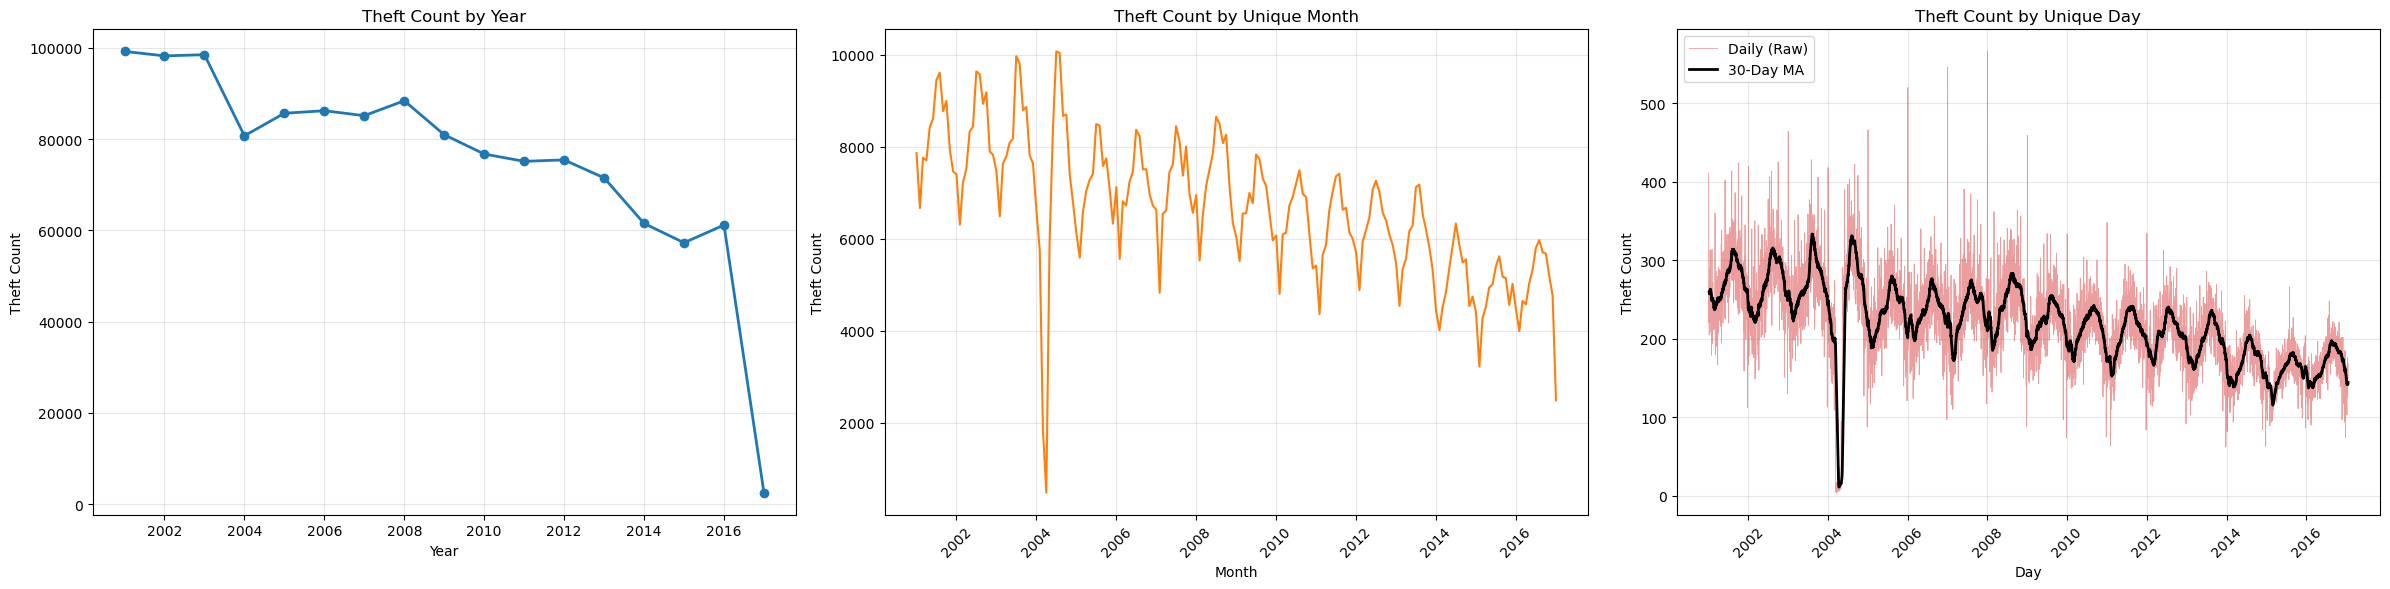

In [25]:
# Theft volume overview by year, month, and day

overview_frame = Theft_data.loc[:, ["Date"]].copy()
overview_frame["Year"] = overview_frame["Date"].dt.year
overview_frame["YearMonth"] = overview_frame["Date"].dt.to_period("M")
overview_frame["CalendarDate"] = overview_frame["Date"].dt.normalize()

theft_by_year = (
    overview_frame.groupby("Year").size().rename("theft_count").to_frame().sort_index()
)

theft_by_month = (
    overview_frame.groupby("YearMonth").size().rename("theft_count").to_frame().sort_index()
)
theft_by_month_display = theft_by_month.copy()
theft_by_month_display.index = theft_by_month_display.index.astype(str)

theft_by_day = (
    overview_frame.groupby("CalendarDate").size().rename("theft_count").to_frame().sort_index()
)
theft_by_day_display = theft_by_day.copy()
theft_by_day_display.index = theft_by_day_display.index.strftime("%Y-%m-%d")

# Keep raw daily counts and add a 30-day trend line for readability.
daily_count_30d_ma = theft_by_day["theft_count"].rolling(window=30, min_periods=7).mean()

print("Theft count by year:")
display(theft_by_year)

print("Theft count by unique month:")
display(theft_by_month_display)

print("Theft count by unique day (sample):")
display(theft_by_day_display.head(20))

# One row with three charts: year, month, day
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=False)

# Yearly trend
axes[0].plot(theft_by_year.index, theft_by_year["theft_count"], marker="o", linewidth=2, color="tab:blue")
axes[0].set_title("Theft Count by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Theft Count")
axes[0].grid(True, alpha=0.3)

# Monthly trend
month_x = theft_by_month.index.to_timestamp()
axes[1].plot(month_x, theft_by_month["theft_count"], linewidth=1.5, color="tab:orange")
axes[1].set_title("Theft Count by Unique Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Theft Count")
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

# Daily trend (raw + 30-day moving average)
axes[2].plot(theft_by_day.index, theft_by_day["theft_count"], linewidth=0.6, alpha=0.45, color="tab:red", label="Daily (Raw)")
axes[2].plot(daily_count_30d_ma.index, daily_count_30d_ma, linewidth=2, color="black", label="30-Day MA")
axes[2].set_title("Theft Count by Unique Day")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Theft Count")
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

# Reusable exports for later modeling/feature steps
theft_overview = {
    "year": theft_by_year,
    "month": theft_by_month,
    "day": theft_by_day,
}

del overview_frame, theft_by_year, theft_by_month, theft_by_month_display, theft_by_day, theft_by_day_display, daily_count_30d_ma

### Time Trends by Key Location Fields

Before drilling into 2004-2005, we inspect Year/Month/Day trends for key fields: `Location Description`, `District`, `Ward`, and `Location`.

Location Description: 102 categories


C:\Users\hanpeng\AppData\Local\Temp\ipykernel_51532\1655394583.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


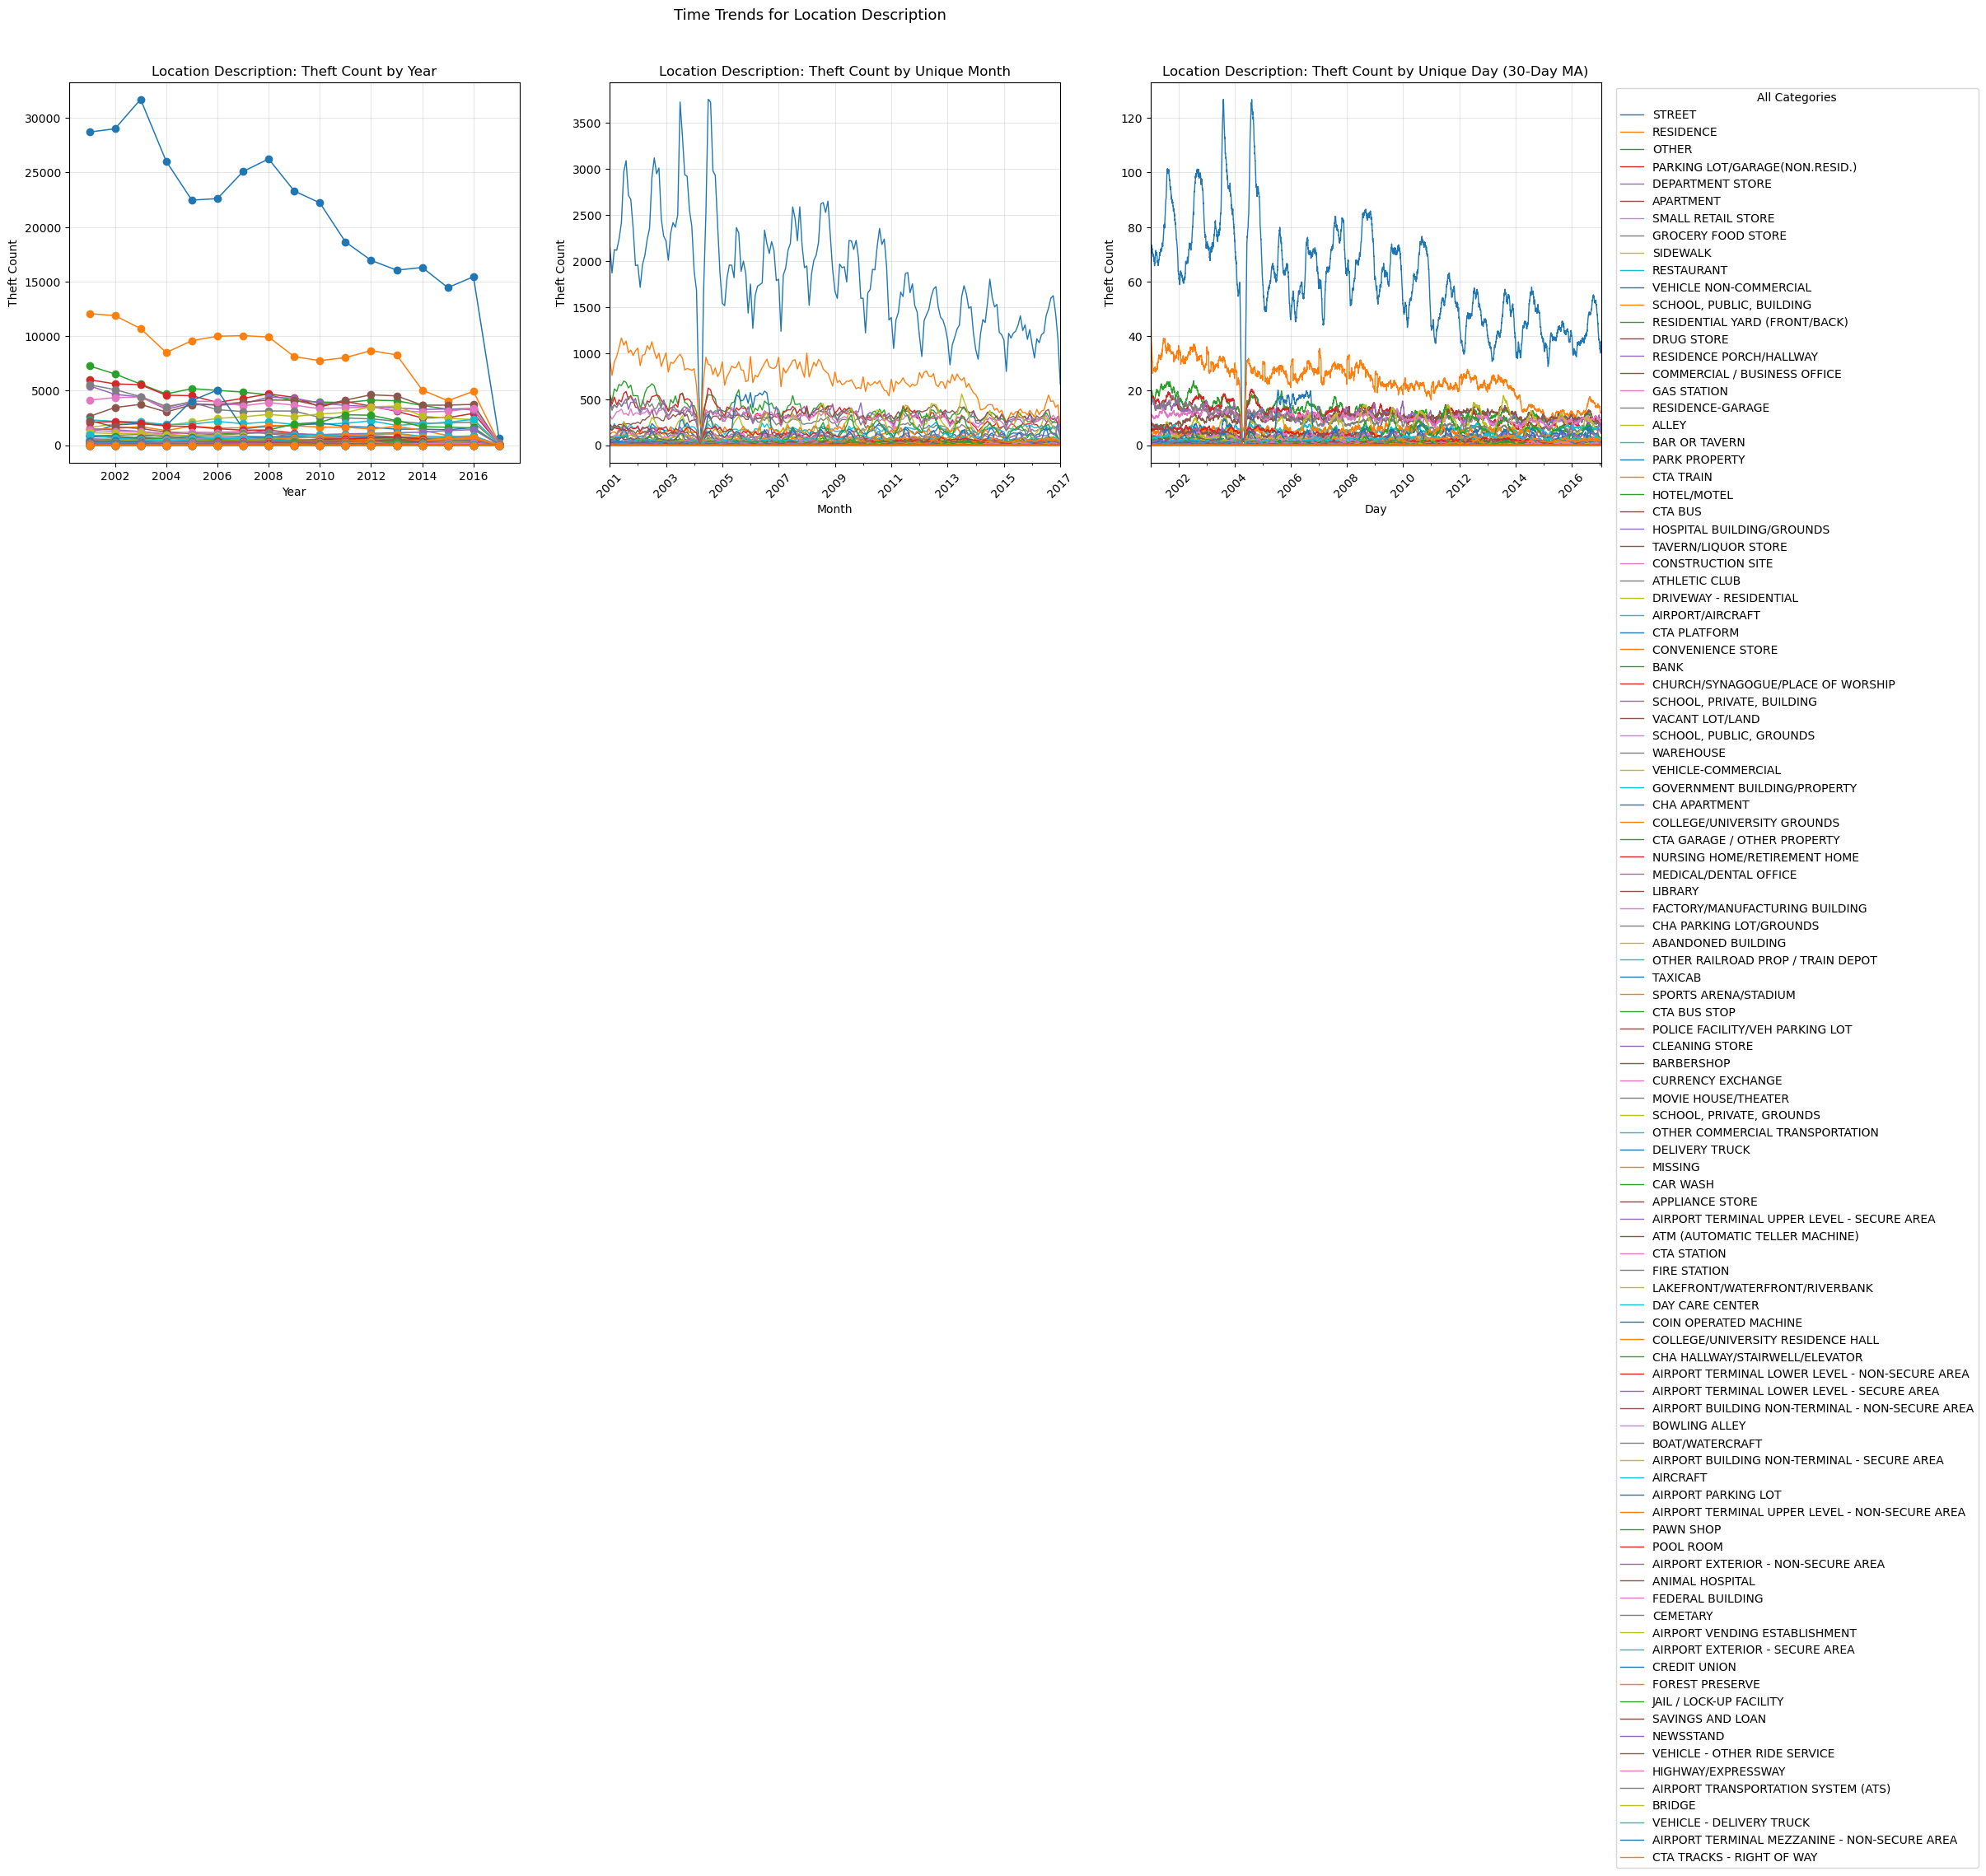

District: 26 categories


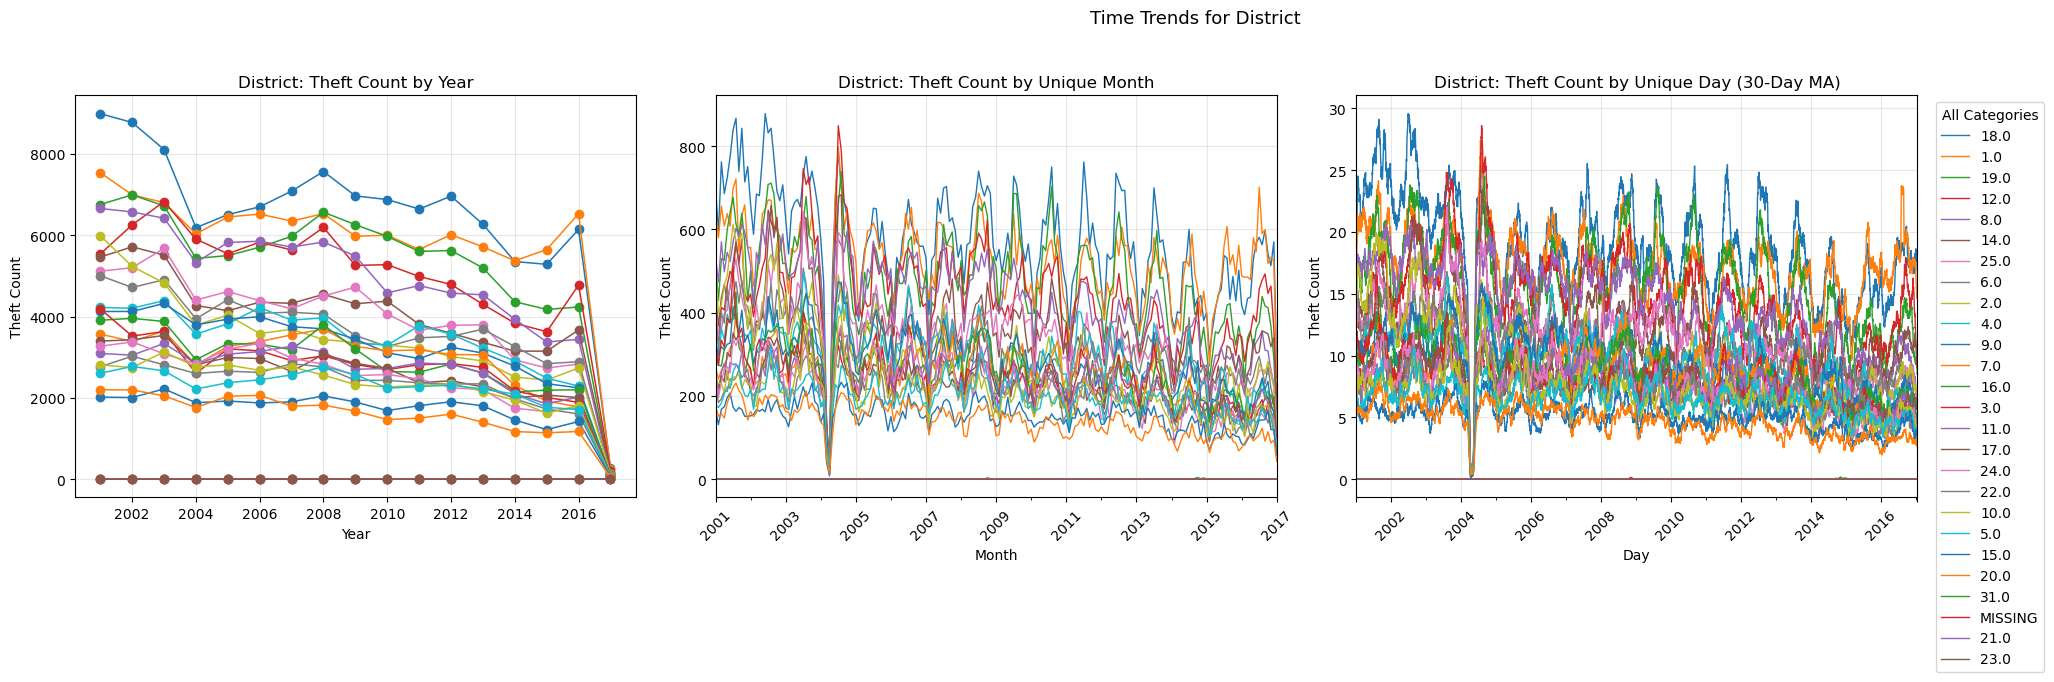

Ward: 51 categories


C:\Users\hanpeng\AppData\Local\Temp\ipykernel_51532\1655394583.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


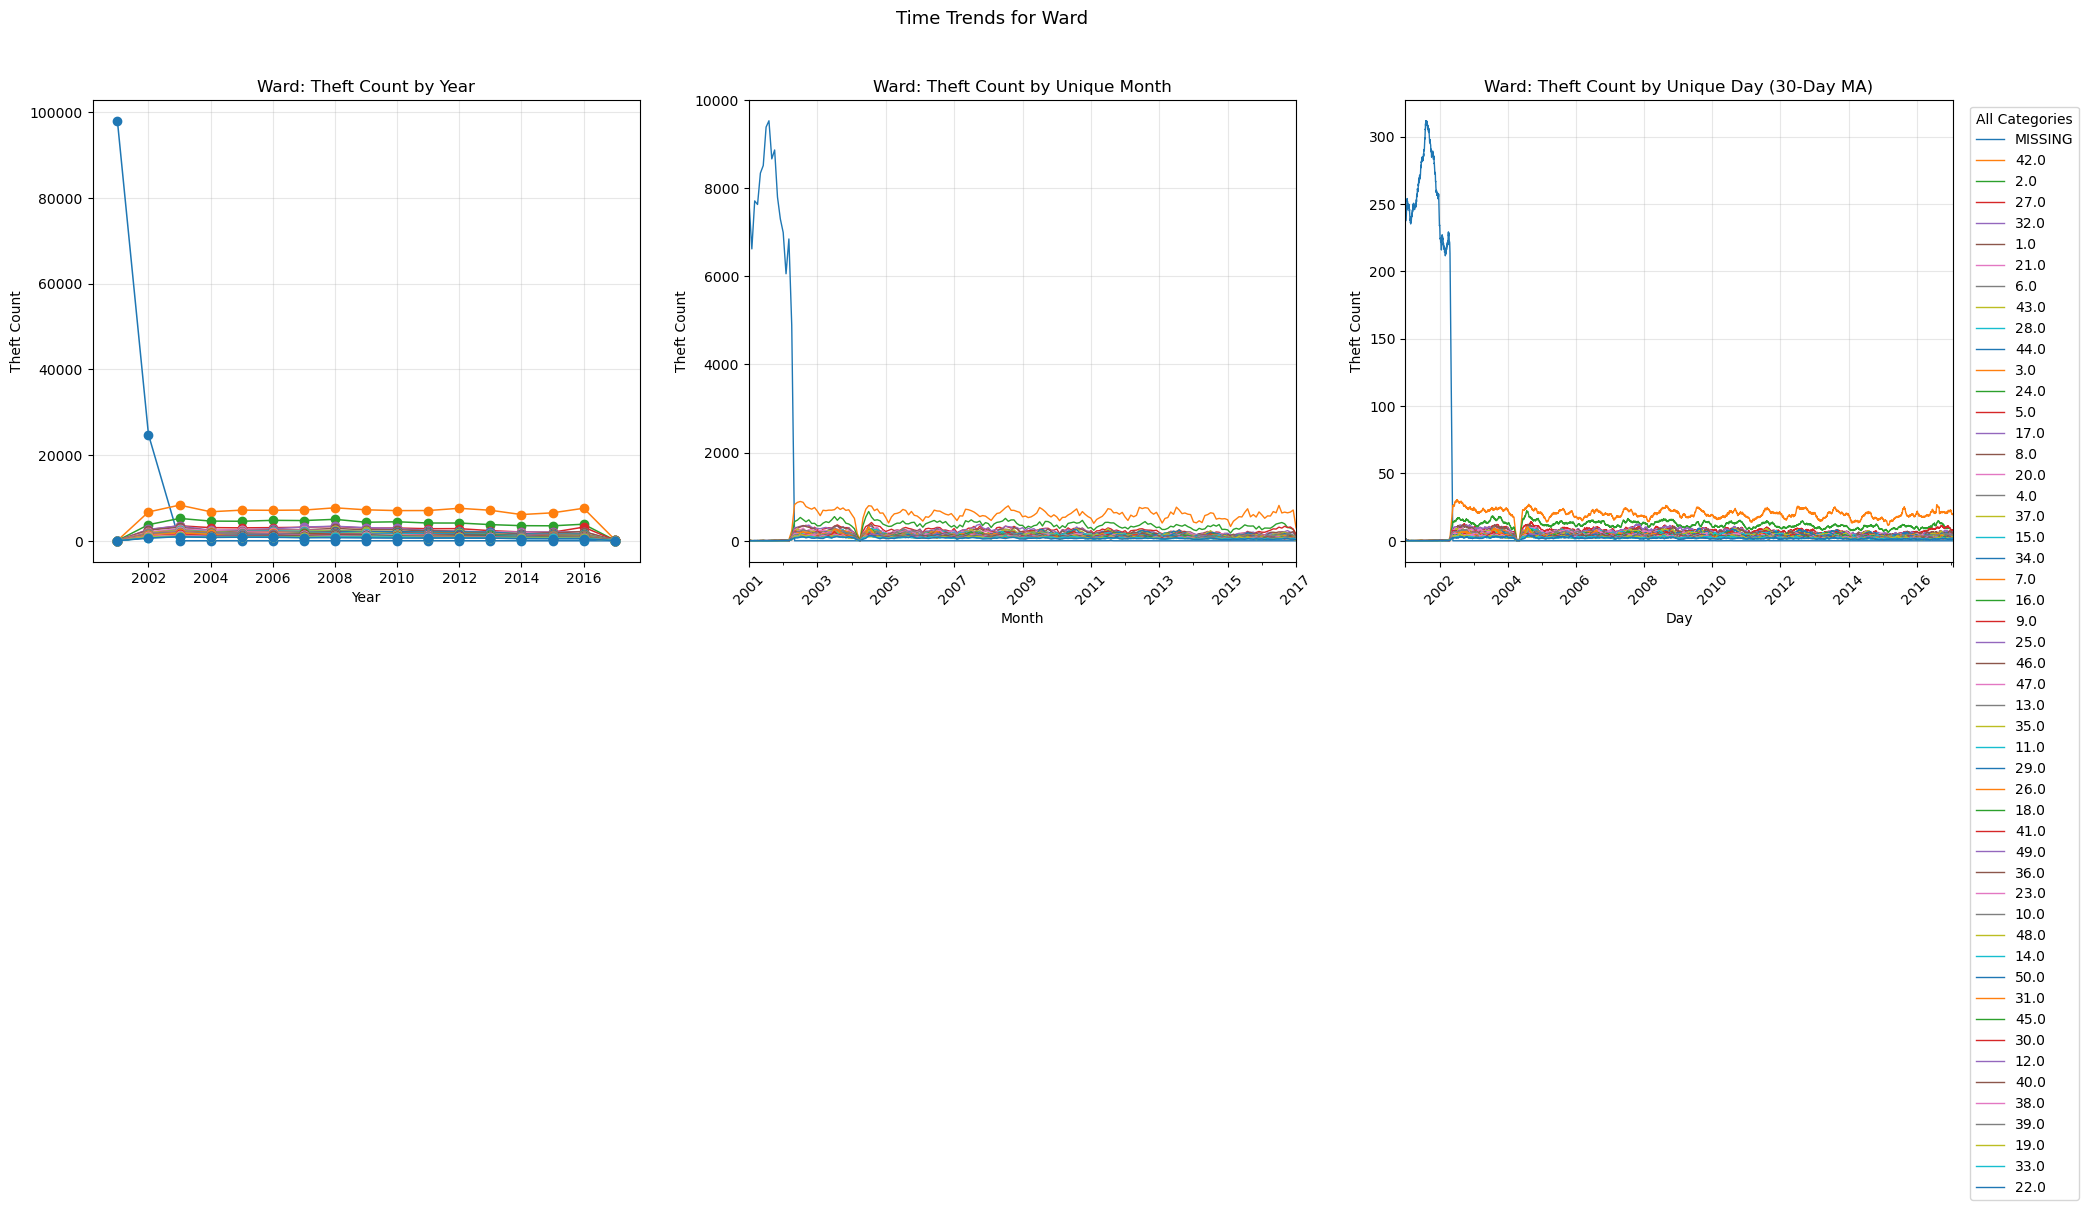

Location (rounded to 0.1 deg): 18 categories


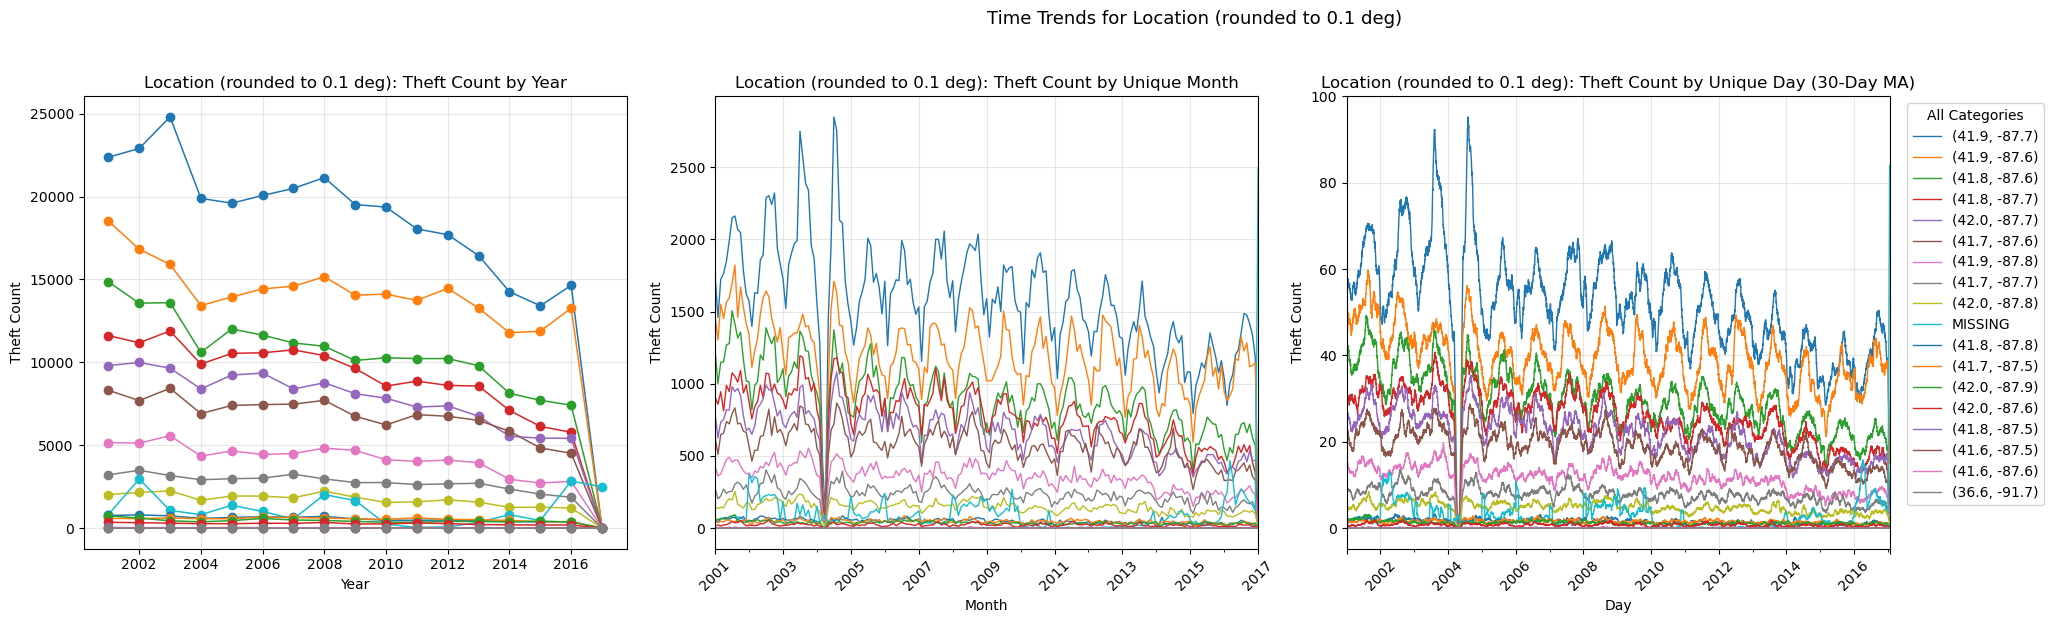

In [26]:
key_fields = ["Location Description", "District", "Ward", "Location"]

trend_frame = Theft_data[["Date"] + key_fields].copy()
trend_frame["Year"] = trend_frame["Date"].dt.year
trend_frame["YearMonth"] = trend_frame["Date"].dt.to_period("M")
trend_frame["CalendarDate"] = trend_frame["Date"].dt.normalize()

# Guardrail for rendering feasibility.
max_categories_to_plot = 300


def to_location_bin_0p1(value):
    """Map raw '(lat, lon)' text to 0.1-degree bins, e.g. '(41.9, -87.6)'."""
    if pd.isna(value):
        return "MISSING"

    text = str(value).strip()
    if not text or text.upper() == "NAN":
        return "MISSING"

    try:
        text = text.strip("()")
        lat_str, lon_str = [part.strip() for part in text.split(",", 1)]
        lat = round(float(lat_str), 1)
        lon = round(float(lon_str), 1)
        return f"({lat:.1f}, {lon:.1f})"
    except Exception:
        return "MISSING"


for field in key_fields:
    grouped_frame = trend_frame[["Year", "YearMonth", "CalendarDate", field]].copy()
    year_pivot = month_pivot = day_pivot = day_smoothed = None
    year_totals = month_totals = day_totals = day_totals_smoothed = None

    if field == "Location":
        grouped_frame["category"] = grouped_frame[field].apply(to_location_bin_0p1)
        field_label = "Location (rounded to 0.1 deg)"
    else:
        grouped_frame["category"] = grouped_frame[field].fillna("MISSING")
        field_label = field

    all_values = grouped_frame["category"].value_counts().index.tolist()
    n_values = len(all_values)

    print(f"{field_label}: {n_values:,} categories")

    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=False)

    if n_values <= max_categories_to_plot:
        year_pivot = grouped_frame.groupby(["Year", "category"]).size().unstack(fill_value=0).reindex(columns=all_values, fill_value=0)
        month_pivot = grouped_frame.groupby(["YearMonth", "category"]).size().unstack(fill_value=0).reindex(columns=all_values, fill_value=0)
        day_pivot = grouped_frame.groupby(["CalendarDate", "category"]).size().unstack(fill_value=0).reindex(columns=all_values, fill_value=0)

        day_smoothed = day_pivot.rolling(window=30, min_periods=7).mean()

        # Year
        year_pivot.plot(ax=axes[0], marker="o", linewidth=1.1)
        axes[0].set_title(f"{field_label}: Theft Count by Year")
        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Theft Count")
        axes[0].grid(True, alpha=0.3)

        # Month
        month_plot = month_pivot.copy()
        month_plot.index = month_plot.index.to_timestamp()
        month_plot.plot(ax=axes[1], linewidth=1.0)
        axes[1].set_title(f"{field_label}: Theft Count by Unique Month")
        axes[1].set_xlabel("Month")
        axes[1].set_ylabel("Theft Count")
        axes[1].grid(True, alpha=0.3)
        axes[1].tick_params(axis="x", rotation=45)

        # Day
        day_smoothed.plot(ax=axes[2], linewidth=1.0)
        axes[2].set_title(f"{field_label}: Theft Count by Unique Day (30-Day MA)")
        axes[2].set_xlabel("Day")
        axes[2].set_ylabel("Theft Count")
        axes[2].grid(True, alpha=0.3)
        axes[2].tick_params(axis="x", rotation=45)

        handles, labels = axes[2].get_legend_handles_labels()
        for ax in axes:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        axes[2].legend(handles, labels, title="All Categories", bbox_to_anchor=(1.02, 1), loc="upper left")

    else:
        # Fallback for still-too-high cardinality fields.
        year_totals = grouped_frame.groupby("Year").size()
        month_totals = grouped_frame.groupby("YearMonth").size()
        day_totals = grouped_frame.groupby("CalendarDate").size()
        day_totals_smoothed = day_totals.rolling(window=30, min_periods=7).mean()

        axes[0].plot(year_totals.index, year_totals.values, marker="o", linewidth=2, color="tab:blue")
        axes[0].set_title(f"{field_label}: Total Theft Count by Year")
        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Theft Count")
        axes[0].grid(True, alpha=0.3)

        month_x = month_totals.index.to_timestamp()
        axes[1].plot(month_x, month_totals.values, linewidth=1.6, color="tab:orange")
        axes[1].set_title(f"{field_label}: Total Theft Count by Month")
        axes[1].set_xlabel("Month")
        axes[1].set_ylabel("Theft Count")
        axes[1].grid(True, alpha=0.3)
        axes[1].tick_params(axis="x", rotation=45)

        axes[2].plot(day_totals.index, day_totals.values, linewidth=0.6, alpha=0.4, color="tab:red", label="Daily (Raw)")
        axes[2].plot(day_totals_smoothed.index, day_totals_smoothed.values, linewidth=2, color="black", label="30-Day MA")
        axes[2].set_title(f"{field_label}: Total Theft Count by Day")
        axes[2].set_xlabel("Day")
        axes[2].set_ylabel("Theft Count")
        axes[2].grid(True, alpha=0.3)
        axes[2].tick_params(axis="x", rotation=45)
        axes[2].legend(loc="upper left")

        note = f"{field_label} still has {n_values:,} categories; full all-category line plots are not renderable in memory."
        print(note)

    plt.suptitle(f"Time Trends for {field_label}", y=1.03, fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.show()
    
    del grouped_frame, year_pivot, month_pivot, day_pivot, day_smoothed, year_totals, month_totals, day_totals, day_totals_smoothed
    gc.collect()
    
    

We see that the data looks weird between roughly 2004 to 2005.

Let's dive into that year a little deeper

## Handling the 2004-2005 anomaly

The time-series EDA suggests a structural break around 2004-2005. Rather than impute across a regime shift, we will define a trusted modeling window using monthly data-quality and volume-stability rules, then restrict forecasting to that window.

Reference period for stability calibration: 2005-01
Missingness thresholds (%):
{'Ward': 0.5, 'Community Area': 0.5, 'Location': 4.04, 'District': 0.5}

Trusted monthly segments:


,start,end,n_months
0,2005-01,2015-12,132
1,2016-09,2016-12,4
2,2016-05,2016-05,1



Chosen modeling window: 2005-01-01 to 2015-12-31
Rows kept for modeling: 844,040 / 1,284,608 (65.7%)


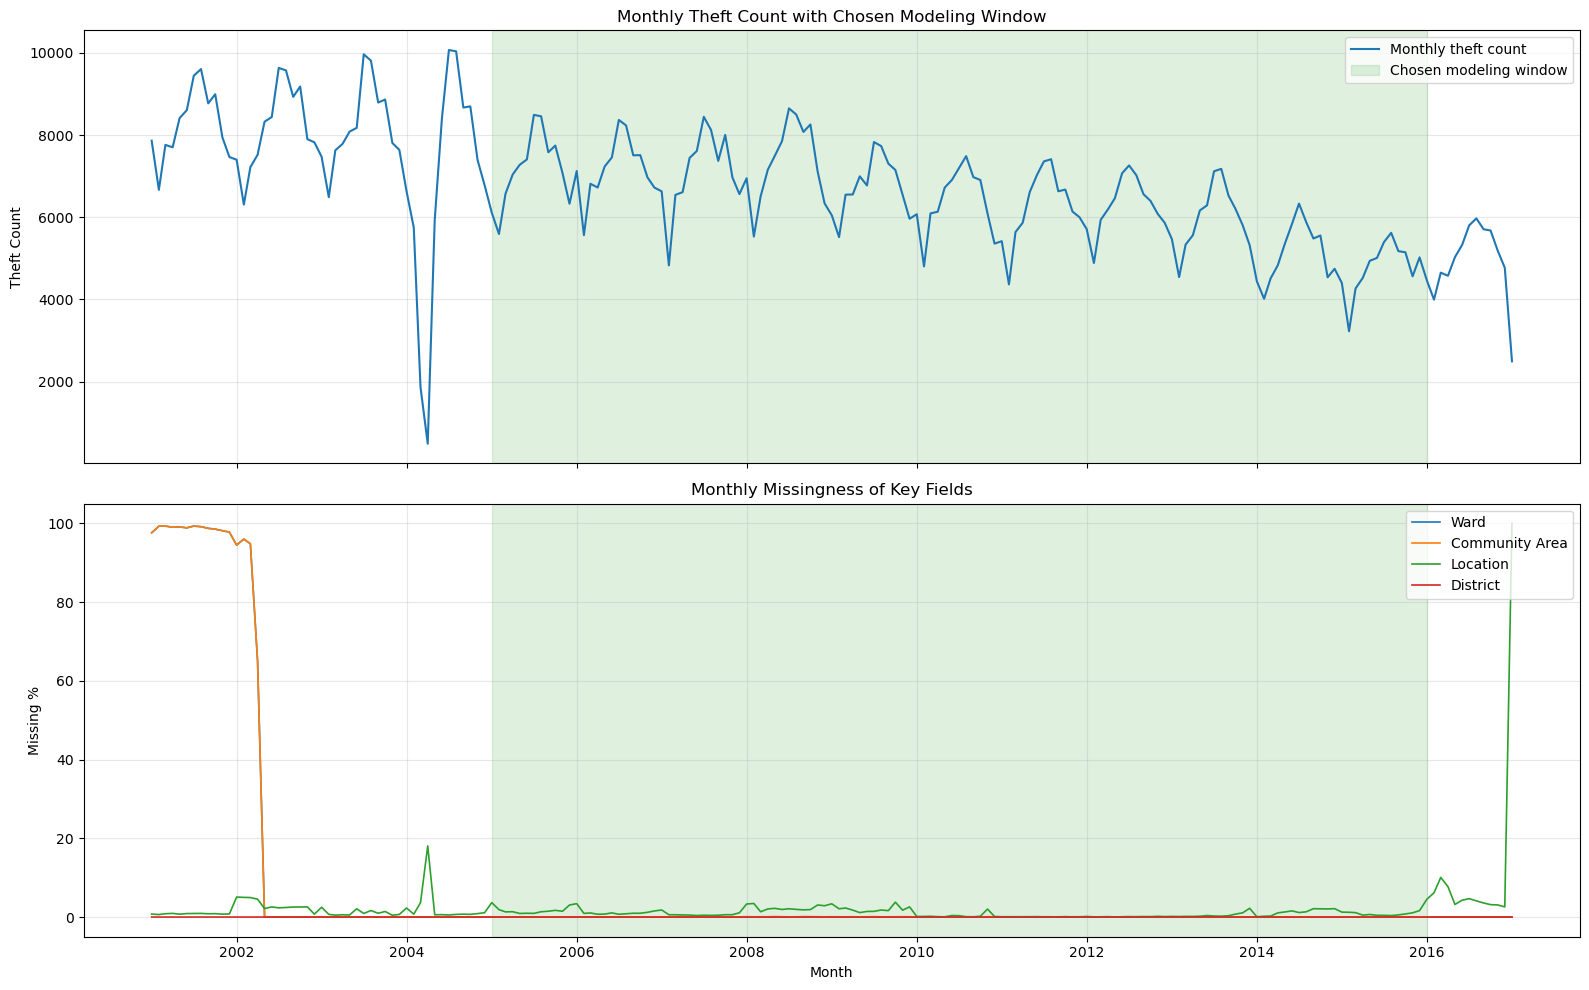

In [27]:
# Investigate the 2004-2005 anomaly and define a trusted modeling window
requested_quality_features = ["Ward", "Community Area", "Location", "District"]
monthly_quality = theft_overview["month"].copy().rename(columns={"theft_count": "y"})
monthly_quality = monthly_quality.reindex(missing_by_month.index).copy()

quality_features = []
for col in requested_quality_features:
    monthly_quality[f"{col}_missing_pct"] = missing_by_month[col] if col in missing_by_month.columns else 0.0
    quality_features.append(col)

monthly_quality["missing_score"] = monthly_quality[[f"{col}_missing_pct" for col in quality_features]].mean(axis=1)

reference_start = pd.Period("2005-01", freq="M")
reference_mask = monthly_quality.index >= reference_start
reference_counts = monthly_quality.loc[reference_mask, "y"].dropna()

count_median = reference_counts.median()
count_mad = (reference_counts - count_median).abs().median()
if pd.isna(count_mad) or count_mad == 0:
    count_mad = max(reference_counts.std(ddof=0), 1.0)

monthly_quality["count_robust_z"] = 0.6745 * (monthly_quality["y"] - count_median) / count_mad

missing_thresholds = {
    col: max(float(monthly_quality.loc[reference_mask, f"{col}_missing_pct"].quantile(0.95)), 0.5)
    for col in quality_features
}

monthly_quality["stable_missing"] = True
for col in quality_features:
    monthly_quality["stable_missing"] &= monthly_quality[f"{col}_missing_pct"] <= missing_thresholds[col]

monthly_quality["stable_volume"] = monthly_quality["count_robust_z"].abs() <= 3
monthly_quality["trusted_month"] = reference_mask & monthly_quality["stable_missing"] & monthly_quality["stable_volume"]

def find_consecutive_segments(period_values):
    if len(period_values) == 0:
        return []

    ordered = sorted(period_values)
    segments = []
    start = ordered[0]
    prev = ordered[0]

    for current in ordered[1:]:
        if (current - prev).n == 1:
            prev = current
            continue
        segments.append((start, prev))
        start = current
        prev = current

    segments.append((start, prev))
    return segments

trusted_segments = find_consecutive_segments(list(monthly_quality.index[monthly_quality["trusted_month"]]))
trusted_segment_records = [
    {
        "start": str(start),
        "end": str(end),
        "n_months": (end - start).n + 1,
    }
    for start, end in trusted_segments
]

trusted_segments_df = pd.DataFrame(trusted_segment_records)
if not trusted_segments_df.empty:
    trusted_segments_df = trusted_segments_df.sort_values(["n_months", "start"], ascending=[False, True]).reset_index(drop=True)
    best_segment = trusted_segments_df.iloc[0]
    analysis_start = pd.Period(best_segment["start"], freq="M").to_timestamp()
    analysis_end = pd.Period(best_segment["end"], freq="M").to_timestamp(how="end").normalize()
else:
    trusted_segments_df = pd.DataFrame(columns=["start", "end", "n_months"])
    analysis_start = reference_start.to_timestamp()
    analysis_end = Theft_data["Date"].max().normalize()

Theft_model_data = Theft_data[(Theft_data["Date"] >= analysis_start) & (Theft_data["Date"] <= analysis_end)].copy()

print(f"Reference period for stability calibration: {reference_start}")
print("Missingness thresholds (%):")
print({key: round(value, 2) for key, value in missing_thresholds.items()})
print("\nTrusted monthly segments:")
display(trusted_segments_df)
print(f"\nChosen modeling window: {analysis_start.date()} to {analysis_end.date()}")
print(f"Rows kept for modeling: {len(Theft_model_data):,} / {len(Theft_data):,} ({len(Theft_model_data) / len(Theft_data):.1%})")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
axes[0].plot(monthly_quality.index.to_timestamp(), monthly_quality["y"], color="tab:blue", linewidth=1.5, label="Monthly theft count")
axes[0].axvspan(analysis_start, analysis_end, color="tab:green", alpha=0.15, label="Chosen modeling window")
axes[0].set_title("Monthly Theft Count with Chosen Modeling Window")
axes[0].set_ylabel("Theft Count")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

for col in quality_features:
    axes[1].plot(monthly_quality.index.to_timestamp(), monthly_quality[f"{col}_missing_pct"], linewidth=1.2, label=col)
axes[1].axvspan(analysis_start, analysis_end, color="tab:green", alpha=0.15)
axes[1].set_title("Monthly Missingness of Key Fields")
axes[1].set_ylabel("Missing %")
axes[1].set_xlabel("Month")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Feature Selection for Forecasting

We now move from EDA to forecasting. Since we want future predictions, we only keep deterministic calendar features that are known in advance and screen them with mutual information plus random forest importance before adding the strongest ones as Prophet regressors.

In [28]:
import importlib.util
import subprocess
import sys

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("prophet")
ensure_package("scikit-learn", "sklearn")

from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    valid = denominator != 0
    if not np.any(valid):
        return 0.0
    return float(np.mean(2 * np.abs(y_pred[valid] - y_true[valid]) / denominator[valid]) * 100)

def mape_excluding_zeros(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = y_true != 0
    if not np.any(valid):
        return np.nan
    return float(np.mean(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid])) * 100)

def add_calendar_features(frame):
    feature_frame = frame.copy()
    feature_frame["day_of_week"] = feature_frame["ds"].dt.dayofweek
    feature_frame["day_of_month"] = feature_frame["ds"].dt.day
    feature_frame["month"] = feature_frame["ds"].dt.month
    feature_frame["quarter"] = feature_frame["ds"].dt.quarter
    feature_frame["day_of_year"] = feature_frame["ds"].dt.dayofyear
    feature_frame["is_weekend"] = feature_frame["day_of_week"].isin([5, 6]).astype(int)
    feature_frame["is_month_start"] = feature_frame["ds"].dt.is_month_start.astype(int)
    feature_frame["is_month_end"] = feature_frame["ds"].dt.is_month_end.astype(int)
    feature_frame["is_quarter_start"] = feature_frame["ds"].dt.is_quarter_start.astype(int)
    feature_frame["is_quarter_end"] = feature_frame["ds"].dt.is_quarter_end.astype(int)
    feature_frame["is_year_start"] = feature_frame["ds"].dt.is_year_start.astype(int)
    feature_frame["is_year_end"] = feature_frame["ds"].dt.is_year_end.astype(int)
    feature_frame["is_summer"] = feature_frame["month"].isin([6, 7, 8]).astype(int)
    feature_frame["is_winter_holiday"] = feature_frame["month"].eq(12).astype(int)
    feature_frame["is_payday_window"] = feature_frame["day_of_month"].isin([1, 2, 3, 15, 16, 17, 28, 29, 30, 31]).astype(int)
    return feature_frame

daily_model = (
    Theft_model_data.groupby(Theft_model_data["Date"].dt.normalize())
    .size()
    .rename("y")
    .to_frame()
    .asfreq("D", fill_value=0)
    .reset_index()
    .rename(columns={"Date": "ds"})
)
daily_model["ds"] = pd.to_datetime(daily_model["ds"])
daily_model = add_calendar_features(daily_model)

candidate_features = [
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "is_year_start",
    "is_year_end",
    "is_summer",
    "is_winter_holiday",
    "is_payday_window",
]

X = daily_model[candidate_features]
y = daily_model["y"]

mi_scores = pd.Series(
    mutual_info_regression(X, y, discrete_features=True, random_state=42),
    index=candidate_features,
    name="mutual_info",
).sort_values(ascending=False)

rf_model = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
 )
rf_model.fit(X, y)
rf_scores = pd.Series(rf_model.feature_importances_, index=candidate_features, name="random_forest_importance").sort_values(ascending=False)

feature_ranking = pd.concat([mi_scores, rf_scores], axis=1).fillna(0)
feature_ranking["combined_rank"] = (
    feature_ranking["mutual_info"].rank(ascending=False, method="average")
    + feature_ranking["random_forest_importance"].rank(ascending=False, method="average")
)
feature_ranking = feature_ranking.sort_values(["combined_rank", "mutual_info", "random_forest_importance"])

selected_regressors = feature_ranking.head(4).index.tolist()

print("Feature ranking for future-known regressors:")
display(feature_ranking)
print(f"Selected regressors for Prophet: {selected_regressors}")
print(f"Modeling sample length: {len(daily_model):,} daily observations")

Feature ranking for future-known regressors:


,mutual_info,random_forest_importance,combined_rank
is_summer,0.072325,0.428039,2.0
is_month_start,0.039227,0.293198,4.0
is_weekend,0.007687,0.149435,9.0
is_winter_holiday,0.016071,0.031191,9.0
is_quarter_start,0.016395,0.008355,10.0
is_year_start,0.007618,0.070402,11.0
is_payday_window,0.014318,0.009369,11.0
is_month_end,0.000000,0.004598,17.0
is_quarter_end,0.000000,0.003131,18.0
is_year_end,0.000000,0.002283,19.0


Selected regressors for Prophet: ['is_summer', 'is_month_start', 'is_weekend', 'is_winter_holiday']
Modeling sample length: 4,017 daily observations


## Prophet Forecasting and Evaluation

We use the selected calendar regressors in a Prophet model, evaluate it on a held-out daily test window, and then produce a forward-looking theft forecast.

In [29]:
# Train a Prophet model, evaluate on a holdout window, and forecast future theft volume
holdout_days = min(180, max(90, len(daily_model) // 5))
minimum_training_days = 365

if len(daily_model) <= minimum_training_days + 30:
    raise ValueError("Not enough daily observations in the trusted window for a meaningful Prophet backtest.")

if len(daily_model) - holdout_days < minimum_training_days:
    holdout_days = max(30, len(daily_model) - minimum_training_days)

train_df = daily_model.iloc[:-holdout_days].copy()
test_df = daily_model.iloc[-holdout_days:].copy()

prophet_regressors = selected_regressors.copy()
prophet_train = train_df[["ds", "y"] + prophet_regressors].copy()

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="additive",
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    interval_width=0.95,
)
prophet_model.add_country_holidays(country_name="US")
for regressor in prophet_regressors:
    prophet_model.add_regressor(regressor)

prophet_model.fit(prophet_train)

history_forecast = prophet_model.predict(daily_model[["ds"] + prophet_regressors])
evaluation_frame = test_df[["ds", "y"]].merge(
    history_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left",
)

evaluation_metrics = pd.Series({
    "train_days": len(train_df),
    "test_days": len(test_df),
    "MAE": round(mean_absolute_error(evaluation_frame["y"], evaluation_frame["yhat"]), 3),
    "RMSE": round(np.sqrt(mean_squared_error(evaluation_frame["y"], evaluation_frame["yhat"])), 3),
    "MAPE_excluding_zero_days_pct": round(mape_excluding_zeros(evaluation_frame["y"], evaluation_frame["yhat"]), 3),
    "sMAPE_pct": round(smape(evaluation_frame["y"].to_numpy(), evaluation_frame["yhat"].to_numpy()), 3),
    "prediction_interval_coverage_pct": round(
        ((evaluation_frame["y"].between(evaluation_frame["yhat_lower"], evaluation_frame["yhat_upper"])).mean()) * 100,
        2,
    ),
})

forecast_horizon = 90
future_dates = pd.date_range(daily_model["ds"].max() + pd.Timedelta(days=1), periods=forecast_horizon, freq="D")
future_regressor_frame = add_calendar_features(pd.DataFrame({"ds": future_dates}))
future_forecast = prophet_model.predict(future_regressor_frame[["ds"] + prophet_regressors])[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

print("Backtest metrics on the holdout period:")
display(evaluation_metrics.to_frame(name="value"))

print("Holdout sample:")
display(evaluation_frame.head(10))

print("90-day future forecast sample:")
display(future_forecast.head(10))

21:11:22 - cmdstanpy - INFO - Chain [1] start processing
21:11:23 - cmdstanpy - INFO - Chain [1] done processing


Backtest metrics on the holdout period:


,value
train_days,3837.000
test_days,180.000
MAE,20.581
RMSE,27.391
MAPE_excluding_zero_days_pct,41.382
sMAPE_pct,14.144
prediction_interval_coverage_pct,86.670


Holdout sample:


,ds,y,yhat,yhat_lower,yhat_upper
0,2015-07-05,167,150.764538,109.799738,189.050970
1,2015-07-06,161,182.252313,139.219879,222.779606
2,2015-07-07,176,182.819929,144.524540,223.503137
3,2015-07-08,171,184.221943,144.151375,224.290529
4,2015-07-09,156,182.343961,140.685465,222.750428
5,2015-07-10,196,201.118503,158.452446,242.181885
6,2015-07-11,167,180.235080,138.299454,221.754386
7,2015-07-12,167,155.547137,114.278298,195.642242
8,2015-07-13,177,186.758407,142.456058,226.258743
9,2015-07-14,191,187.004255,145.722328,228.349146


90-day future forecast sample:


,ds,yhat,yhat_lower,yhat_upper
0,2016-01-01,324.248320,282.503270,366.002452
1,2016-01-02,113.085708,71.638139,153.402493
2,2016-01-03,86.964839,45.657043,126.619089
3,2016-01-04,116.894117,73.163881,157.271181
4,2016-01-05,116.013866,70.730100,160.016027
5,2016-01-06,116.083376,74.987154,158.930773
6,2016-01-07,112.990745,73.524957,152.134563
7,2016-01-08,130.668754,90.464590,170.085769
8,2016-01-09,108.804987,68.781648,151.440459
9,2016-01-10,83.248872,38.922569,121.310544


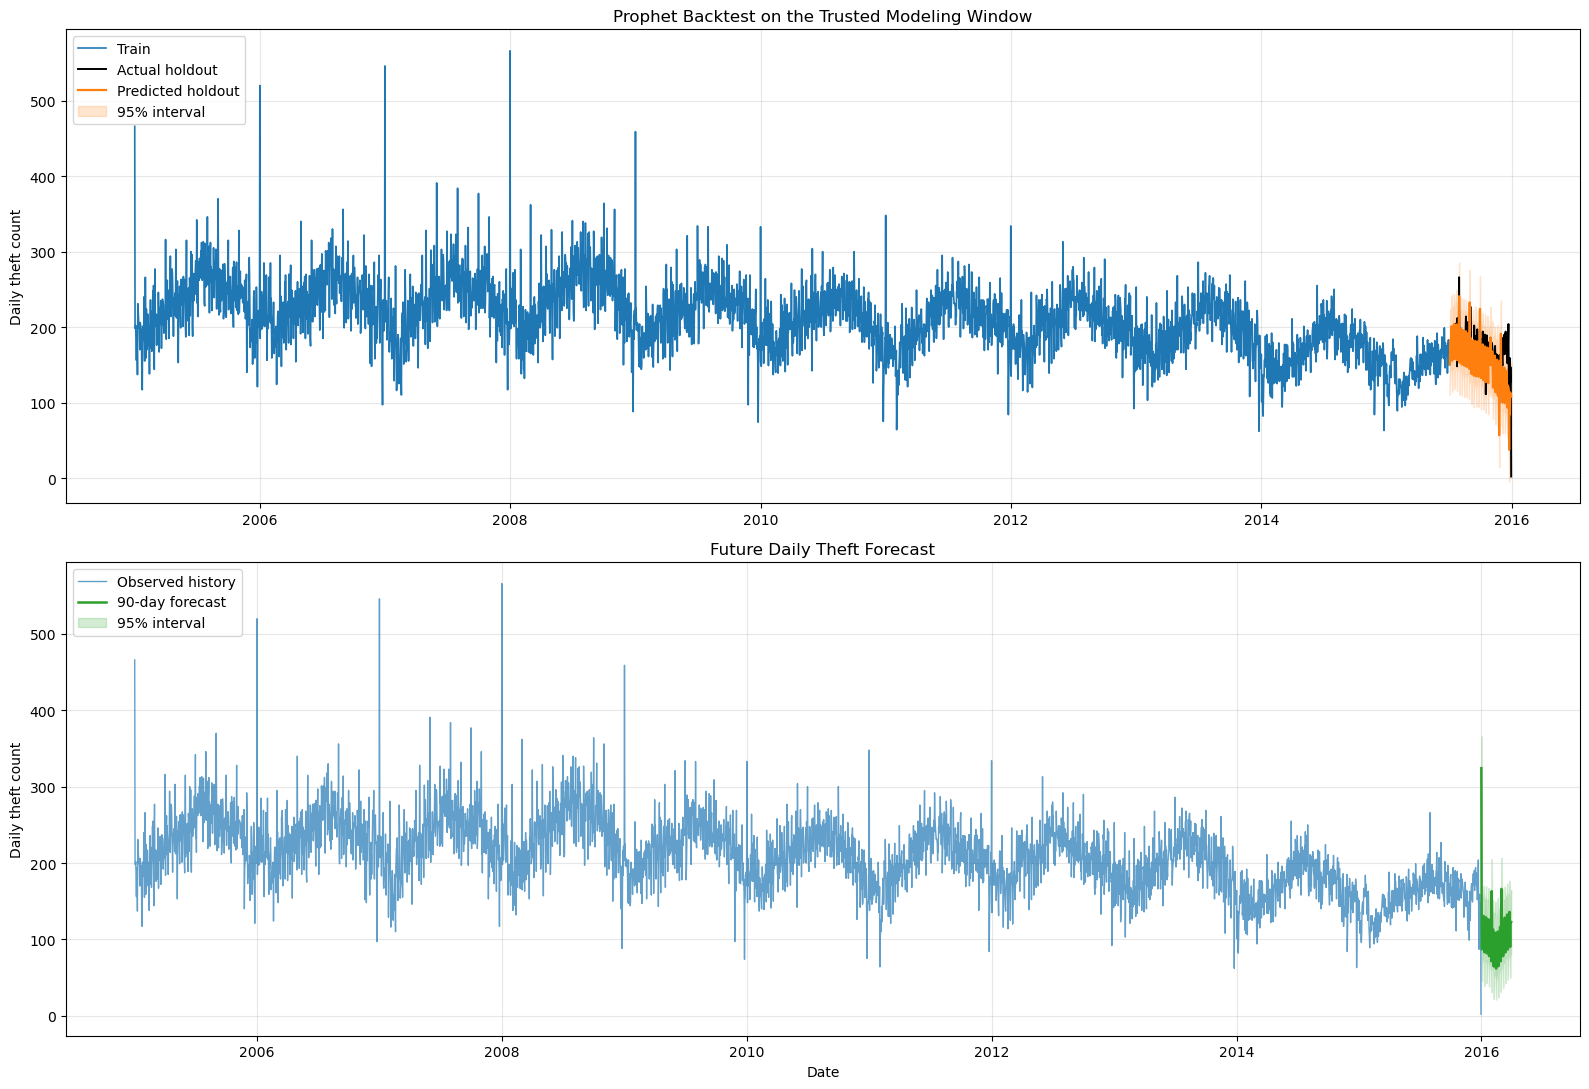

Monthly aggregation of the 90-day forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2016-01-31,3535.930235,2253.564189,4800.187166
1,2016-02-29,2762.262212,1566.451110,3949.262199
2,2016-03-31,3408.454249,2179.683537,4643.215448


In [30]:
# Visualize the backtest and the forward forecast
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=False)

axes[0].plot(train_df["ds"], train_df["y"], color="tab:blue", linewidth=1.2, label="Train")
axes[0].plot(test_df["ds"], test_df["y"], color="black", linewidth=1.4, label="Actual holdout")
axes[0].plot(evaluation_frame["ds"], evaluation_frame["yhat"], color="tab:orange", linewidth=1.6, label="Predicted holdout")
axes[0].fill_between(
    evaluation_frame["ds"],
    evaluation_frame["yhat_lower"],
    evaluation_frame["yhat_upper"],
    color="tab:orange",
    alpha=0.2,
    label="95% interval",
)
axes[0].set_title("Prophet Backtest on the Trusted Modeling Window")
axes[0].set_ylabel("Daily theft count")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

axes[1].plot(daily_model["ds"], daily_model["y"], color="tab:blue", linewidth=1.0, alpha=0.7, label="Observed history")
axes[1].plot(future_forecast["ds"], future_forecast["yhat"], color="tab:green", linewidth=1.8, label="90-day forecast")
axes[1].fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="tab:green",
    alpha=0.2,
    label="95% interval",
)
axes[1].set_title("Future Daily Theft Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily theft count")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

future_forecast_monthly = (
    future_forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]]
    .resample("ME")
    .sum()
    .reset_index()
)

print("Monthly aggregation of the 90-day forecast:")
display(future_forecast_monthly)

## Final Conclusion

This article walked through a complete theft-forecasting workflow for Chicago data:

1. We cleaned and validated the raw multi-year crime data, then focused on theft-only records.
2. We diagnosed the 2004-2005 anomaly and restricted modeling to a trusted time window (2005-01-01 to 2015-12-31).
3. We performed feature screening on future-known calendar signals and selected the most useful regressors.
4. We trained Prophet with these regressors, evaluated on a holdout set (180 days), and generated forward daily and monthly forecasts.

### Key Results

- MAE: 20.58 thefts/day
- RMSE: 27.39 thefts/day
- sMAPE: 14.14%
- MAPE (excluding zero days): 41.38%
- Prediction interval coverage: 86.11% (below nominal 95%, so calibration can be improved)

### Bottom Line

The current pipeline is robust and directly addresses data-quality breaks before training, making it suitable for trend-level theft forecasting and monthly planning.

In [31]:
# Summary of current pipeline evaluation metrics
if "evaluation_metrics" not in globals():
    print("Run the Prophet evaluation cell first so metrics can be displayed.")
else:
    current_mae_day = float(evaluation_metrics.get("MAE", np.nan))
    current_rmse_day = float(evaluation_metrics.get("RMSE", np.nan))
    current_mape = float(evaluation_metrics.get("MAPE_excluding_zero_days_pct", np.nan))
    current_smape = float(evaluation_metrics.get("sMAPE_pct", np.nan))
    current_cov = float(evaluation_metrics.get("prediction_interval_coverage_pct", np.nan))
    train_days = int(evaluation_metrics.get("train_days", np.nan))
    test_days = int(evaluation_metrics.get("test_days", np.nan))

    metrics_summary = pd.DataFrame(
        {
            "metric": [
                "Training window (days)",
                "Test window (days)",
                "MAE (thefts/day)",
                "RMSE (thefts/day)",
                "sMAPE (%)",
                "MAPE excl. zero (%)",
                "Prediction interval coverage (%)",
            ],
            "value": [
                train_days,
                test_days,
                round(current_mae_day, 3),
                round(current_rmse_day, 3),
                round(current_smape, 3),
                round(current_mape, 3),
                round(current_cov, 2),
            ],
        }
    )

    print("Current Pipeline Evaluation Metrics:")
    display(metrics_summary)

Current Pipeline Evaluation Metrics:


,metric,value
0,Training window (days),3837.000
1,Test window (days),180.000
2,MAE (thefts/day),20.581
3,RMSE (thefts/day),27.391
4,sMAPE (%),14.144
5,MAPE excl. zero (%),41.382
6,Prediction interval coverage (%),86.670
